# MPCA - autos2005 dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## autos2005 dataset

In [2]:
# autos2005 dataset
from scientisttools.datasets import autos2005
autos2005._fields

('actif', 'ind_sup', 'sup_var', 'data')

In [3]:
# overall dataset
data = autos2005.data
data.info()

<class 'pandas.DataFrame'>
Index: 45 entries, ALFA 156 to MERCEDES
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   puissance     45 non-null     int64  
 1   cylindree     45 non-null     int64  
 2   vitesse       45 non-null     int64  
 3   longueur      45 non-null     int64  
 4   largeur       45 non-null     int64  
 5   hauteur       45 non-null     int64  
 6   poids         45 non-null     int64  
 7   CO2           45 non-null     int64  
 8   prix          45 non-null     int64  
 9   origine       45 non-null     str    
 10  carburant     45 non-null     str    
 11  type4X4       45 non-null     str    
 12  coffre        38 non-null     float64
 13  reservoir     38 non-null     float64
 14  consommation  38 non-null     float64
 15  surtaxe       38 non-null     str    
dtypes: float64(3), int64(9), str(4)
memory usage: 6.0+ KB


## Instanciation and training

In [4]:
# instanciation
from scientisttools import MPCA
clf = MPCA(ind_sup=range(38,45),sup_var=range(12,16))

### `fit` function

In [5]:
# fit function
clf.fit(data)

,ind_sup,"range(38, 45)"
,sup_var,"range(12, 16)"
,iv,None
,ortho,False
,group,None
,option,'between'
,ncp,5
,row_w,None
,col_w,None
,tol,1e-07
Name,Type,Value


### `fit_transform` function

In [6]:
# fit_transform function - individuals coordinates
ind_coord = clf.fit_transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
ALFA 156,1.606728,2.668778,0.236704,-1.456068,-0.172477
AUDIA3,-1.650412,0.909008,0.288923,-1.571214,0.585690
AUDIA8,4.616883,3.205762,1.093252,-0.766031,0.930640
AVENSIS,-0.231455,-1.173184,0.546345,0.335559,-2.101888
BMW X5,2.802897,-0.335910,2.498885,0.172718,1.152365
BMW530,2.043842,2.467733,0.705405,-1.079725,0.356707
CHRYS300,5.147372,2.382393,-0.993144,-0.485094,-1.278084
CITRONC2,-3.869227,0.084713,-1.683831,0.420796,0.634894
CITRONC4,-1.085360,-0.132608,0.719686,2.239701,-0.504961
CITRONC5,0.939043,2.021035,-1.162404,1.200610,0.334787


### `transform` function

In [7]:
# transform function - individuals coordinates
ind_coord = clf.transform(data)
ind_coord

,Dim1,Dim2,Dim3,Dim4,Dim5
ALFA 156,1.606728,2.668778,0.236704,-1.456068,-0.172477
AUDIA3,-1.650412,0.909008,0.288923,-1.571214,0.585690
AUDIA8,4.616883,3.205762,1.093252,-0.766031,0.930640
AVENSIS,-0.231455,-1.173184,0.546345,0.335559,-2.101888
BMW X5,2.802897,-0.335910,2.498885,0.172718,1.152365
BMW530,2.043842,2.467733,0.705405,-1.079725,0.356707
CHRYS300,5.147372,2.382393,-0.993144,-0.485094,-1.278084
CITRONC2,-3.869227,0.084713,-1.683831,0.420796,0.634894
CITRONC4,-1.085360,-0.132608,0.719686,2.239701,-0.504961
CITRONC5,0.939043,2.021035,-1.162404,1.200610,0.334787


In [8]:
# attributes
from scientisttools import sprintf
sprintf(clf)


**Results of the Mixed Principal Component Analysis (MPCA)**

*The results are available in the following objects:

name                 description
-------------------  -----------------------------------------------------
.call_               summary called parameters
.eig_                eigenvalues
.ind_                results for the individuals
.ind_sup_            results for the supplementary individuals
.levels_             results for the levels
.levels_sup_         results for the supplementary levels
.quali_var_          results for the qualitative variables
.quali_var_sup_      results for the supplementary qualitative variables
.quanti_var_         results for the quantitative variables
.quanti_var_sup_     results for the supplementary quantitative variables
.separate_analyses_  results for the separate analyses
.svd_                results for generalized singular values decomposition
.var_                results for variables



## Eigen values

In [9]:
#eigenvalues
from scientisttools import get_eig
eig =  get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,6.874071,3.276741,42.962945,42.962945
Dim2,3.597331,1.449550,22.483316,65.446261
Dim3,2.147781,0.815016,13.423629,78.869890
Dim4,1.332764,0.608959,8.329776,87.199666
Dim5,0.723805,0.249243,4.523781,91.723447
Dim6,0.474562,0.157680,2.966011,94.689458
Dim7,0.316882,0.119264,1.980511,96.669969
Dim8,0.197618,0.055017,1.235110,97.905079
Dim9,0.142601,0.044899,0.891253,98.796333
Dim10,0.097701,0.045897,0.610633,99.406966


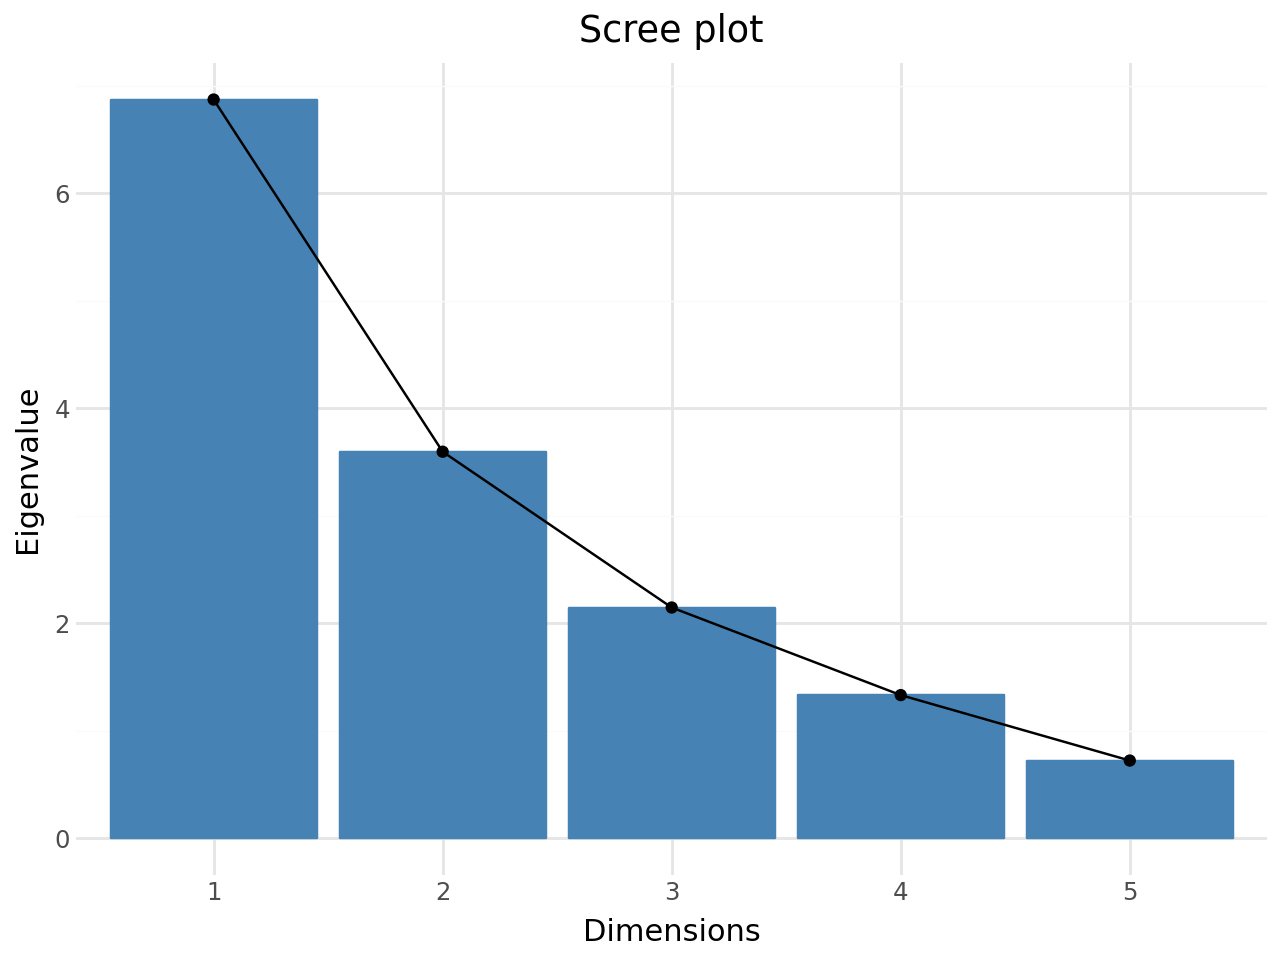

None


In [10]:
# scree plot - eigenvalue
from scientisttools import fviz_screeplot
p = fviz_screeplot(obj=clf,choice="eigenvalue")
print(p.show())

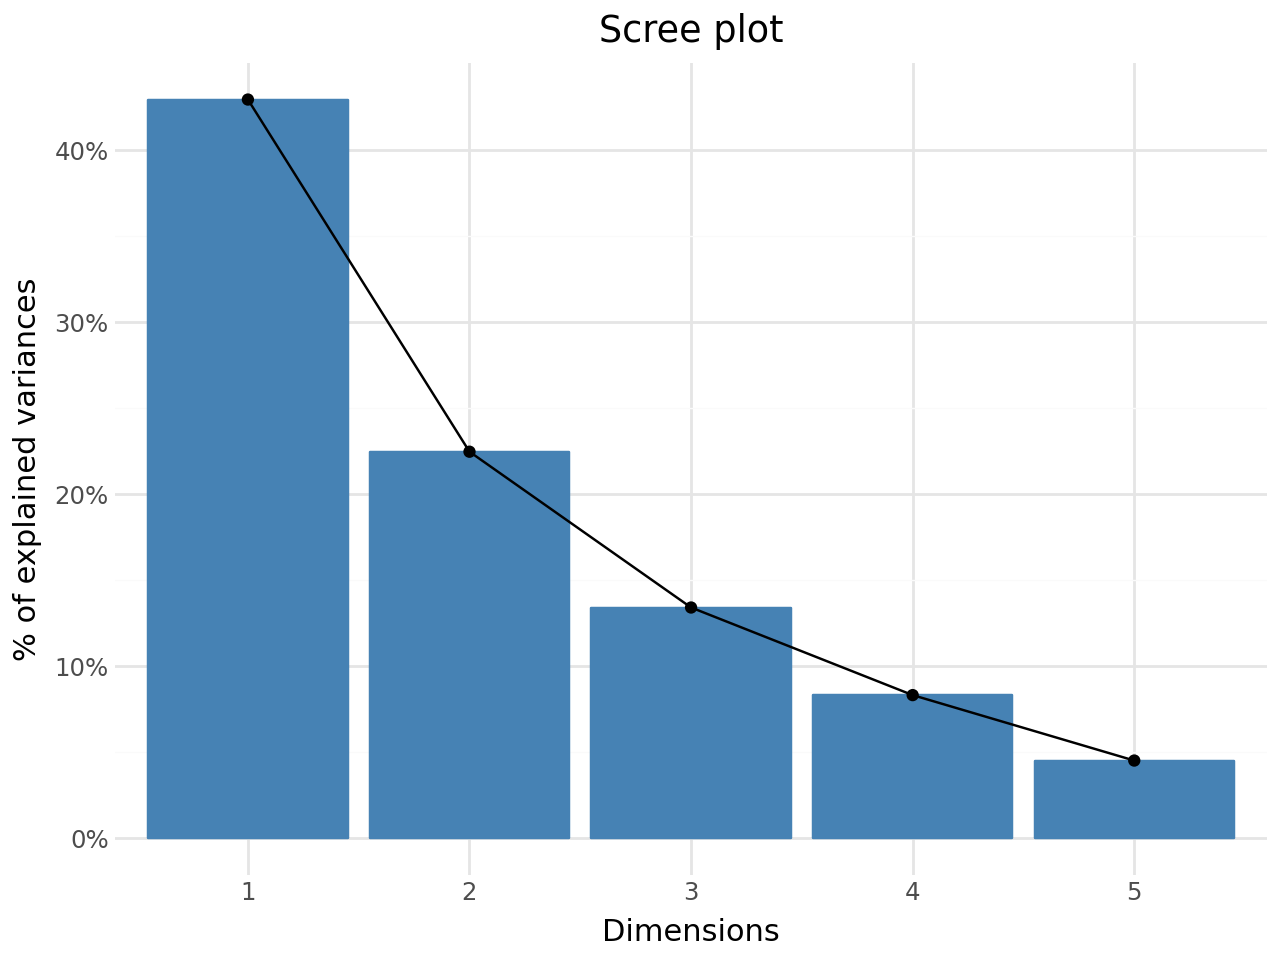

None


In [11]:
# scree plot - proportion
p = fviz_screeplot(obj=clf,choice="proportion")
print(p.show())

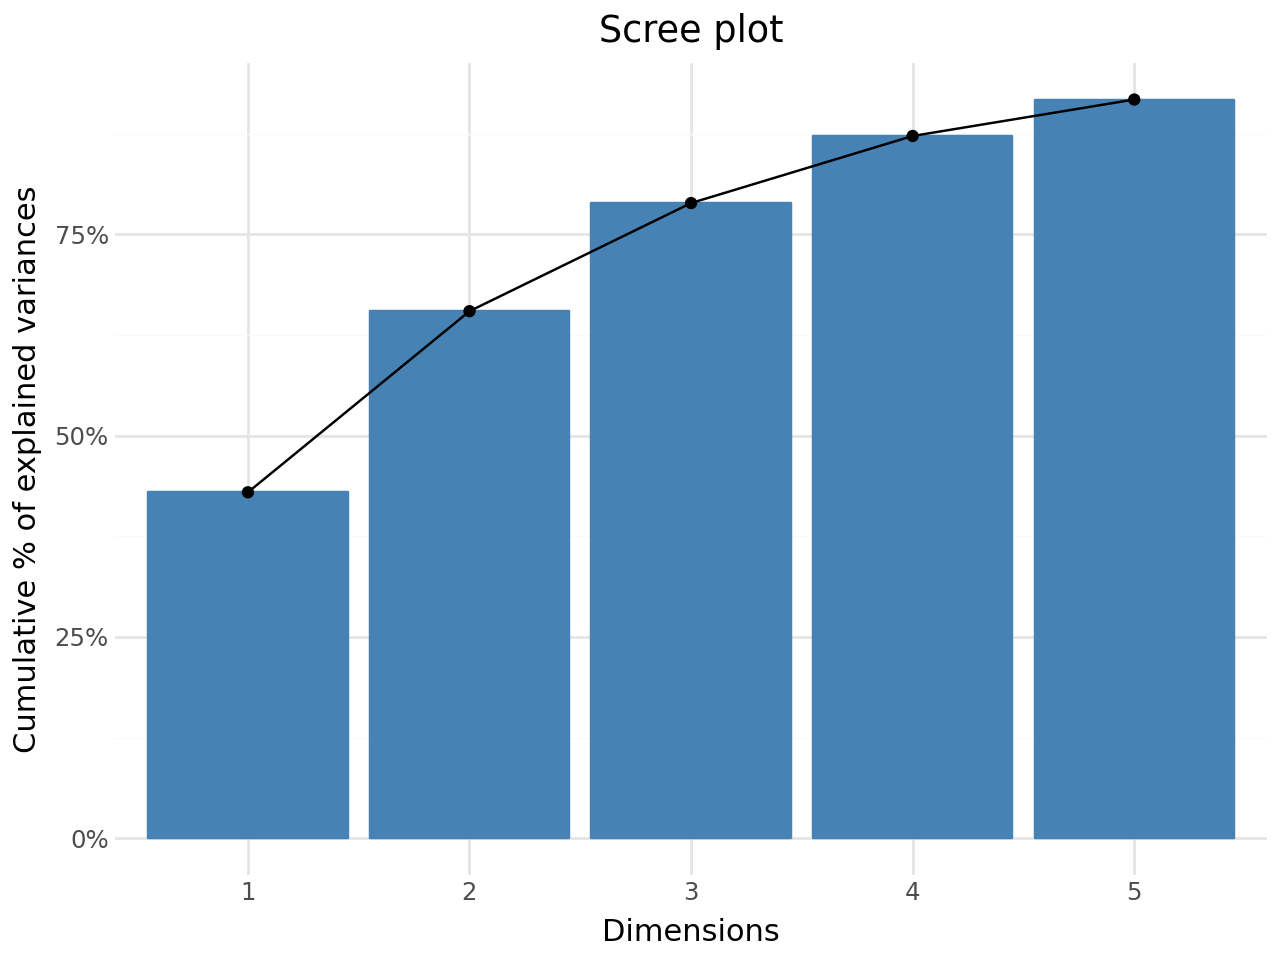

None


In [12]:
# scree plot - cumulative
p = fviz_screeplot(obj=clf,choice="cumulative")
print(p.show())

## Individuals informations

In [13]:
#individuals informations
from scientisttools import get_mix
ind = get_mix(clf)
ind._fields

('coord', 'cos2', 'contrib', 'infos')

### Individuals coordinates

In [14]:
# individuals coordinates
ind.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
ALFA 156,1.606728,2.668778,0.236704,-1.456068,-0.172477
AUDIA3,-1.650412,0.909008,0.288923,-1.571214,0.585690
AUDIA8,4.616883,3.205762,1.093252,-0.766031,0.930640
AVENSIS,-0.231455,-1.173184,0.546345,0.335559,-2.101888
BMW X5,2.802897,-0.335910,2.498885,0.172718,1.152365
BMW530,2.043842,2.467733,0.705405,-1.079725,0.356707
CHRYS300,5.147372,2.382393,-0.993144,-0.485094,-1.278084
CITRONC2,-3.869227,0.084713,-1.683831,0.420796,0.634894
CITRONC4,-1.085360,-0.132608,0.719686,2.239701,-0.504961
CITRONC5,0.939043,2.021035,-1.162404,1.200610,0.334787


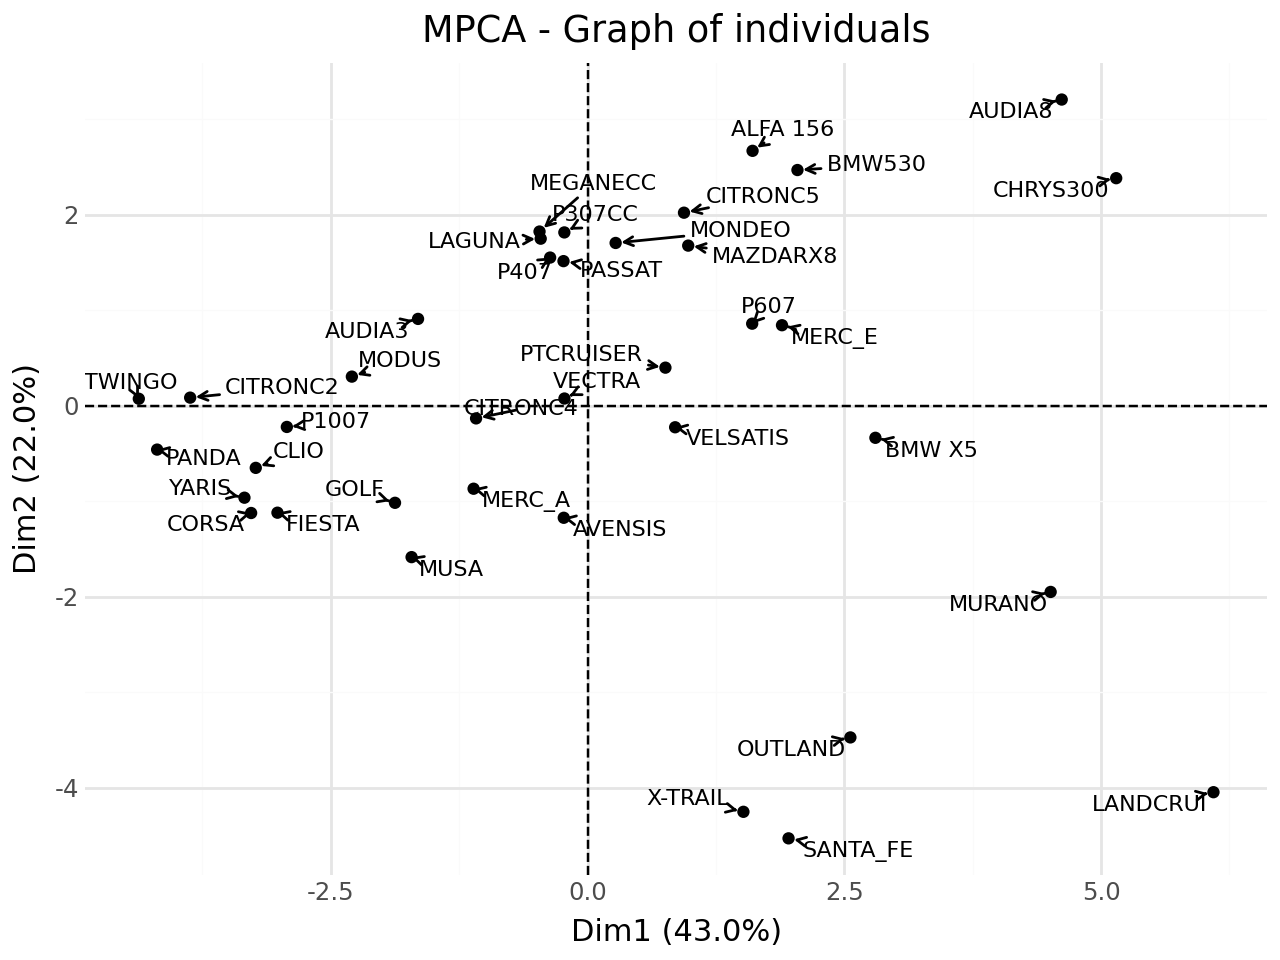

None


In [15]:
# graph of individuals
from scientisttools import fviz_mix
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind = "black",
    repel = True,
    ind_sup = False
)
print(p.show())

### Individuals contributions

In [16]:
# individuals contributions
ind.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
ALFA 156,0.988297,5.210278,0.068650,4.186262,0.108158
AUDIA3,1.042767,0.604465,0.102280,4.874540,1.247186
AUDIA8,8.160188,7.517938,1.464423,1.158659,3.148899
AVENSIS,0.020509,1.006858,0.365730,0.222331,16.062526
BMW X5,3.007577,0.082544,7.651014,0.058903,4.828084
BMW530,1.599178,4.454844,0.609682,2.301914,0.462613
CHRYS300,10.143166,4.152053,1.208511,0.464638,5.939007
CITRONC2,5.731268,0.005250,3.473948,0.349627,1.465539
CITRONC4,0.450972,0.012864,0.634618,9.904745,0.927066
CITRONC5,0.337577,2.988022,1.655543,2.846209,0.407503


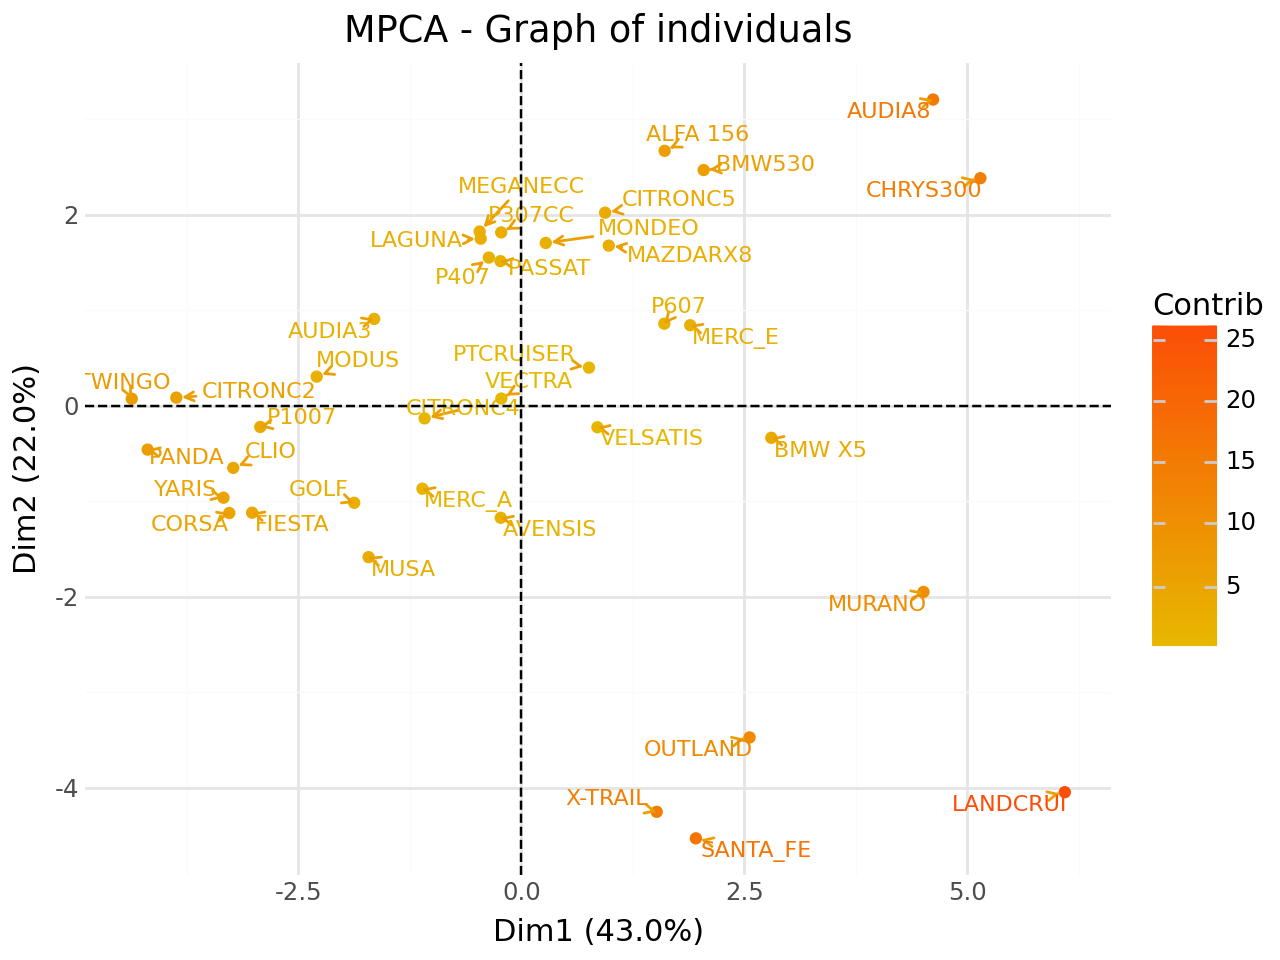

None


In [17]:
# graph of individuals - color by contributions
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind="contrib",
    repel=True,
    ind_sup=False
)
print(p.show())

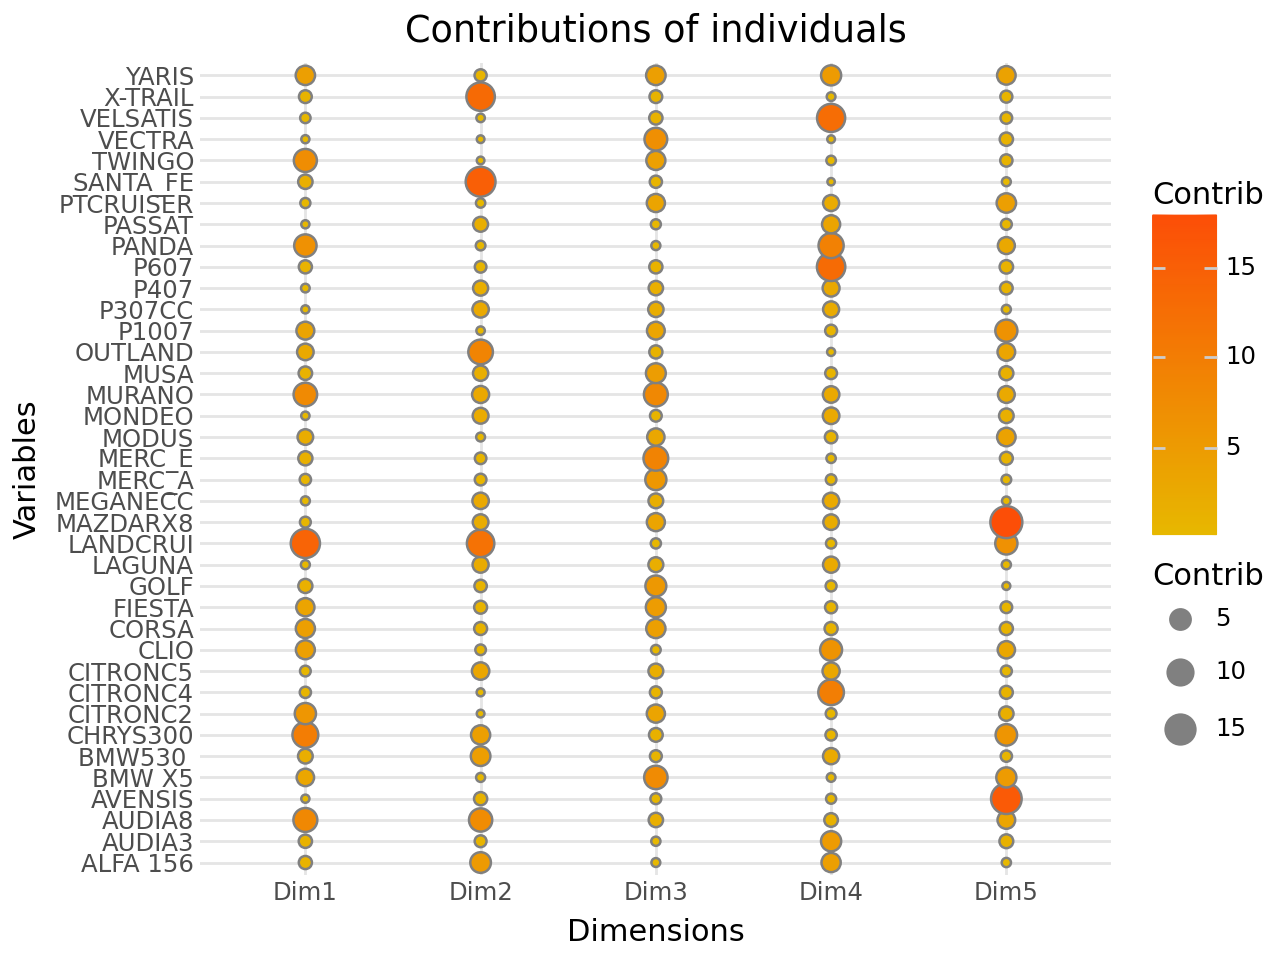

None


In [18]:
# graph 
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=ind.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

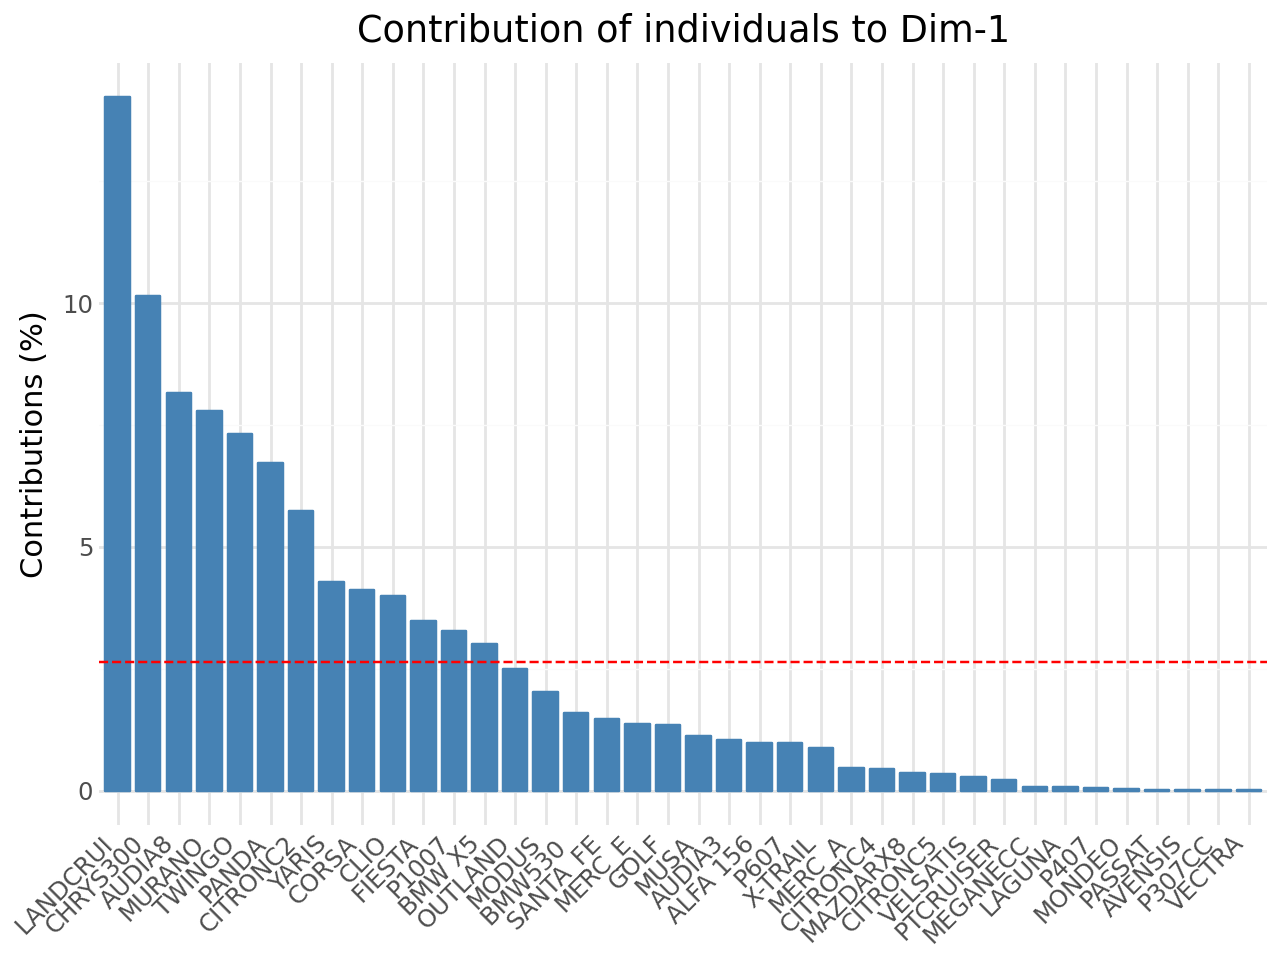

None


In [19]:
# contributions of individuals to axis 1
from scientisttools import fviz_contrib
p = fviz_contrib(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals cos2

In [20]:
# individuals cos2
ind.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
ALFA 156,0.176404,0.486685,0.003829,0.144873,0.002033
AUDIA3,0.377084,0.114390,0.011556,0.341762,0.047489
AUDIA8,0.581679,0.280445,0.032616,0.016013,0.023635
AVENSIS,0.006529,0.167731,0.036376,0.013722,0.538395
BMW X5,0.434560,0.006241,0.345404,0.001650,0.073454
BMW530,0.331044,0.482601,0.039434,0.092388,0.010084
CHRYS300,0.654805,0.140271,0.024376,0.005816,0.040370
CITRONC2,0.804417,0.000386,0.152346,0.009514,0.021659
CITRONC4,0.162491,0.002426,0.071445,0.691931,0.035172
CITRONC5,0.105345,0.487968,0.161420,0.172205,0.013390


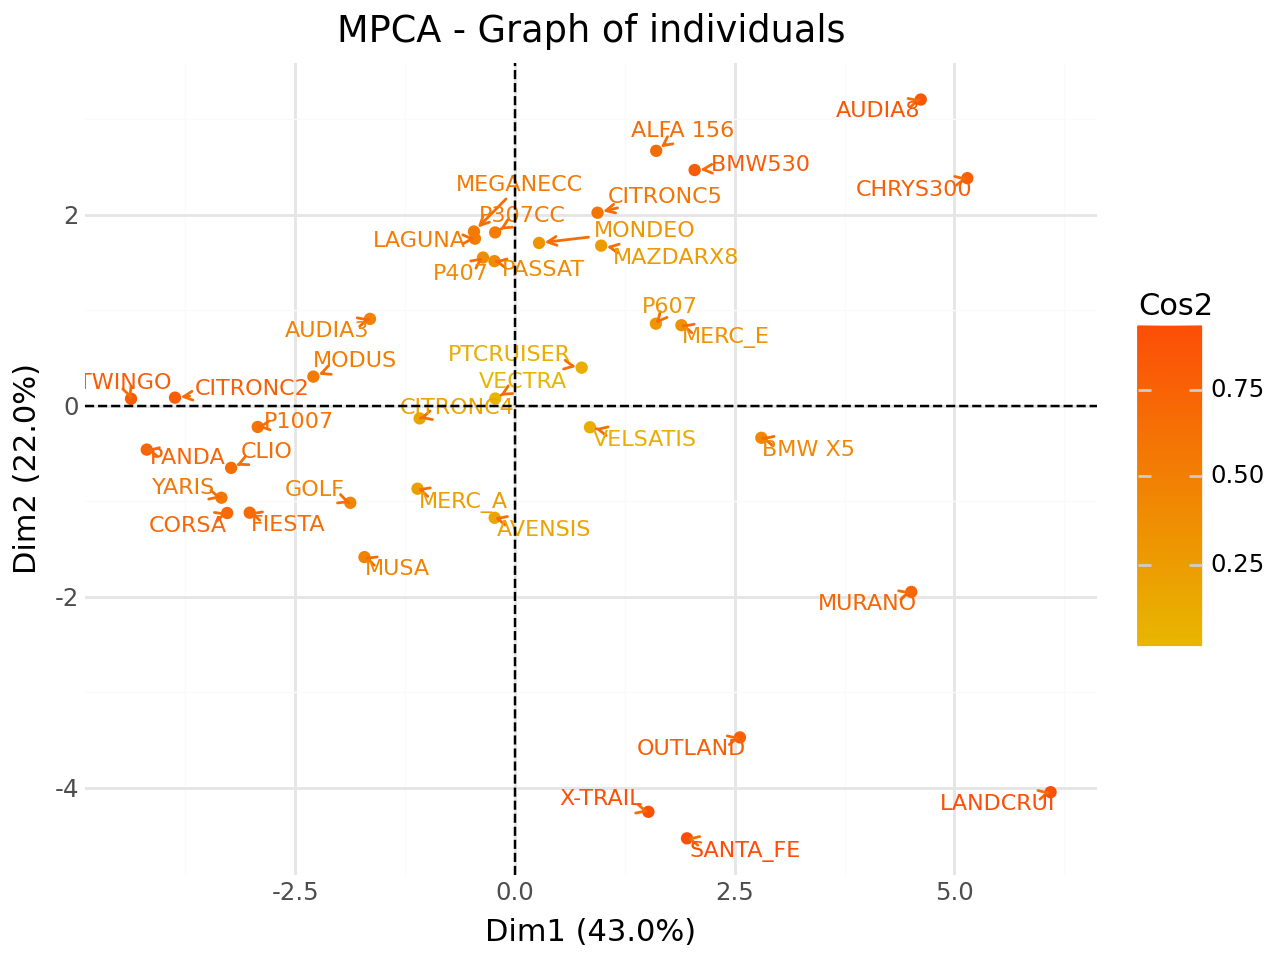

None


In [21]:
# graph of individuals - color by cosinus
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind="cos2",
    repel=True,
    ind_sup=False
)
print(p.show())

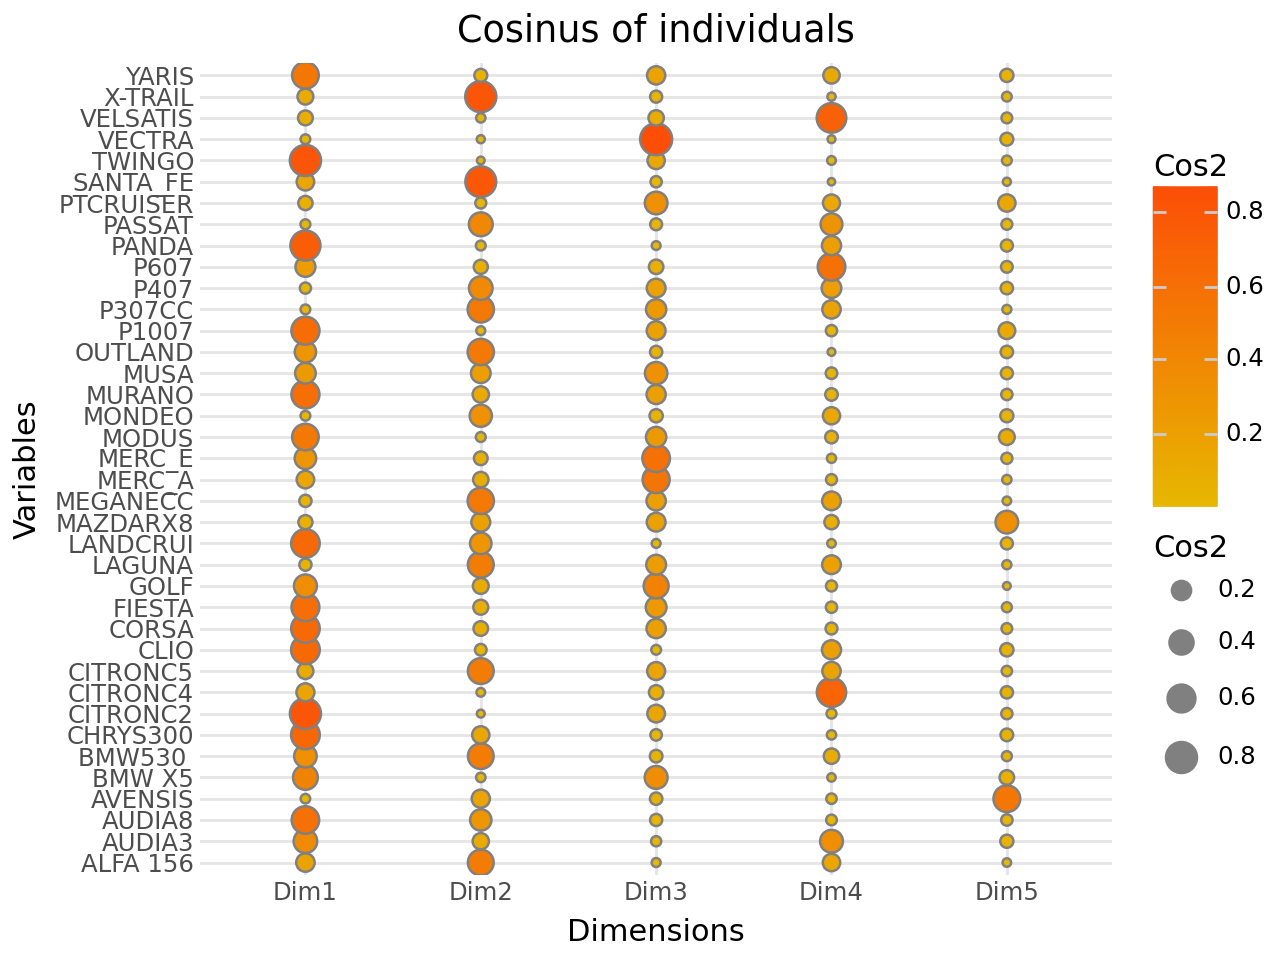

None


In [22]:
# graph of cosinus
p = fviz_corrplot(
    X=ind.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

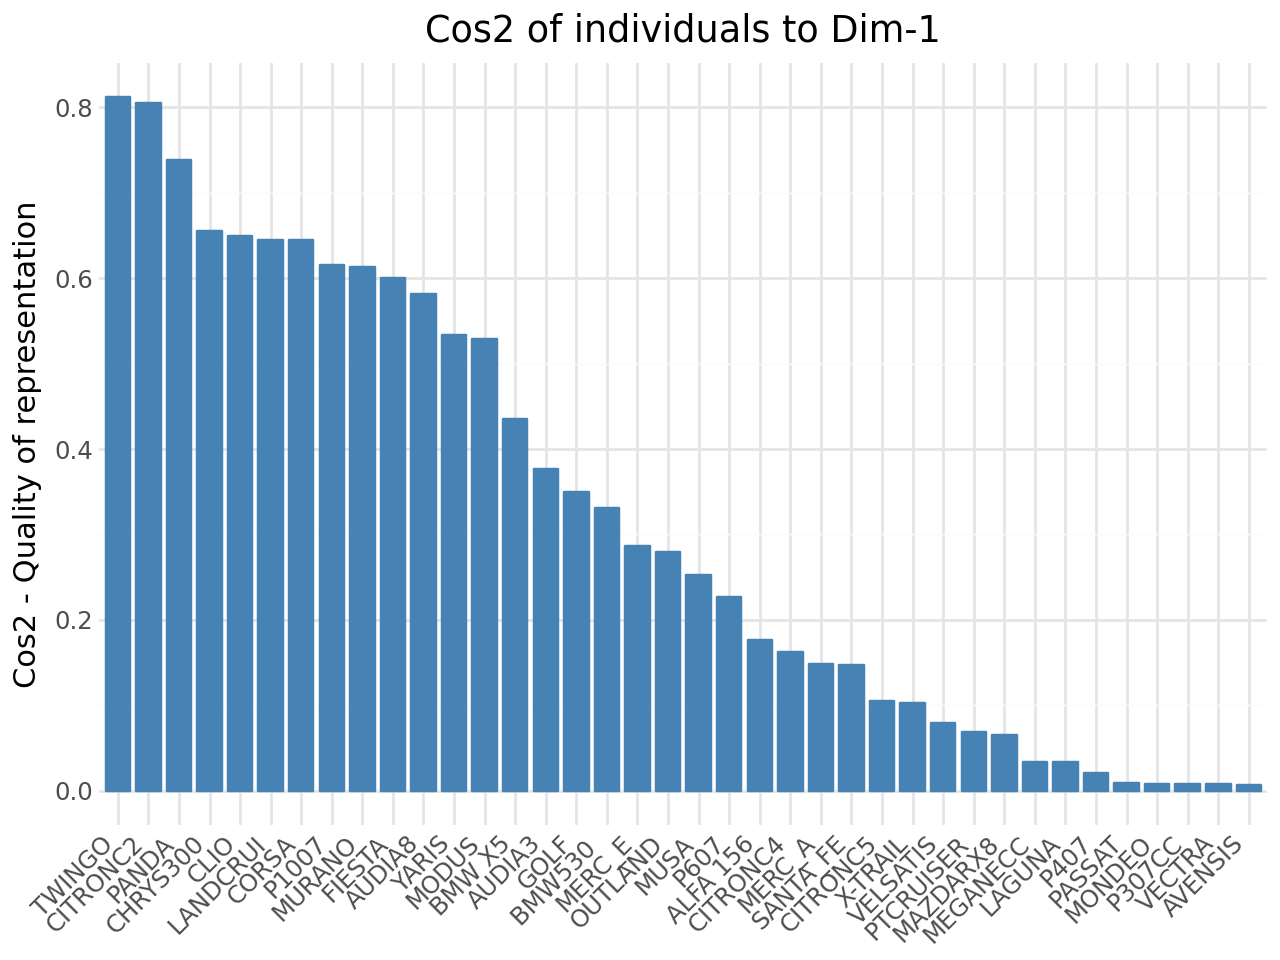

None


In [23]:
# cosinus of individuals to axis 1
from scientisttools import fviz_cos2
p = fviz_cos2(
    obj=clf,
    choice="ind"
)
print(p.show())

### Individuals additionals informations

In [24]:
# individuals additionals informations
ind.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
ALFA 156,0.026316,14.634480,0.385118,2.406987
AUDIA3,0.026316,7.223484,0.190092,1.188073
AUDIA8,0.026316,36.644965,0.964341,6.027132
AVENSIS,0.026316,8.205742,0.215941,1.349629
BMW X5,0.026316,18.078594,0.475752,2.973453
BMW530,0.026316,12.618523,0.332066,2.075415
CHRYS300,0.026316,40.463074,1.064818,6.655111
CITRONC2,0.026316,18.610879,0.489760,3.061000
CITRONC4,0.026316,7.249654,0.190780,1.192377
CITRONC5,0.026316,8.370603,0.220279,1.376744


## Quantitative variables informations

In [25]:
#quantitative variables informations
from scientisttools import get_mix
quanti_var = get_mix(clf,"quanti_var")
quanti_var._fields

('coord', 'cos2', 'contrib', 'infos')

### Quantitative variables coordinates

In [26]:
# quantitative variables coordinates
quanti_var.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
puissance,0.877895,0.381137,-0.055933,-0.012753,-0.149169
cylindree,0.869803,0.165418,0.077873,0.001348,0.048122
vitesse,0.628313,0.636105,0.118274,0.105666,-0.213708
longueur,0.872954,0.222756,0.154535,0.159602,-0.063023
largeur,0.858535,0.143450,0.176445,0.098860,0.188082
hauteur,0.380106,-0.748060,-0.046568,-0.026613,0.405155
poids,0.929250,-0.125792,0.103053,0.180298,0.125525
CO2,0.880698,0.229561,-0.285506,-0.126672,0.003053
prix,0.918840,0.181829,0.152224,0.036117,0.094099
Autres,0.454759,-0.501899,-0.456587,-0.250255,-0.472200


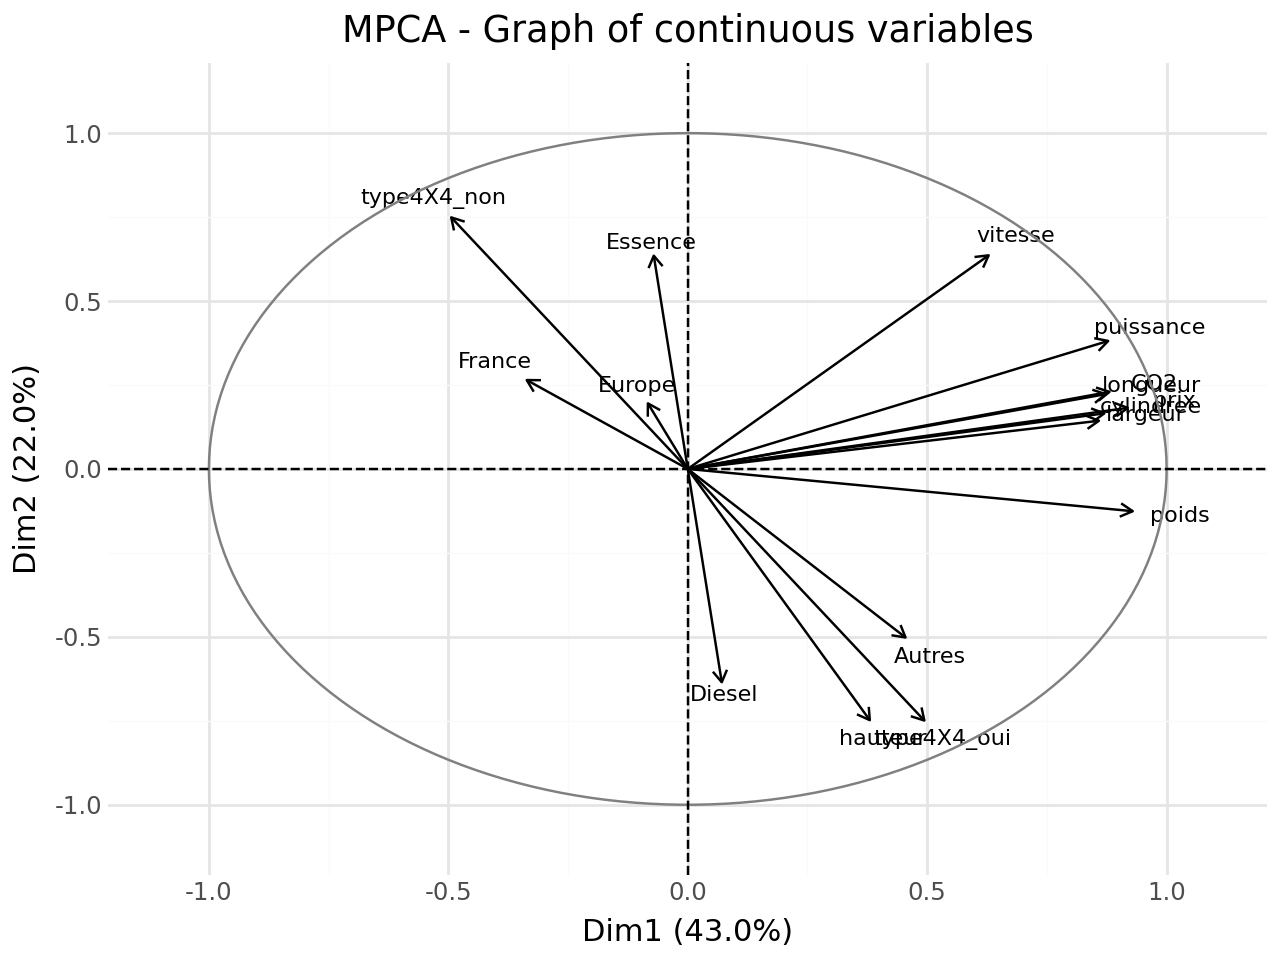

None


In [27]:
# graph of variables - correlation circle
p = fviz_mix(
    obj=clf,
    choice="quanti_var",
    repel=True,
    quanti_sup=False
)
print(p.show())

### Quantitative variables contributions

In [28]:
# quantitative variables contributions
quanti_var.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
puissance,11.211682,4.038134,0.145663,0.012203,3.074207
cylindree,11.005964,0.760654,0.282351,0.000136,0.319942
vitesse,5.742991,11.248054,0.651310,0.837760,6.309875
longueur,11.085834,1.379360,1.111889,1.911272,0.548755
largeur,10.722658,0.572035,1.449533,0.733311,4.887342
hauteur,2.101823,15.555791,0.100970,0.053140,22.678868
poids,12.561790,0.439874,0.494459,2.439086,2.176885
CO2,11.283397,1.464925,3.795263,1.203941,0.001288
prix,12.281915,0.919069,1.078893,0.097877,1.223341
Autres,3.008495,7.002475,9.706384,4.699058,30.805649


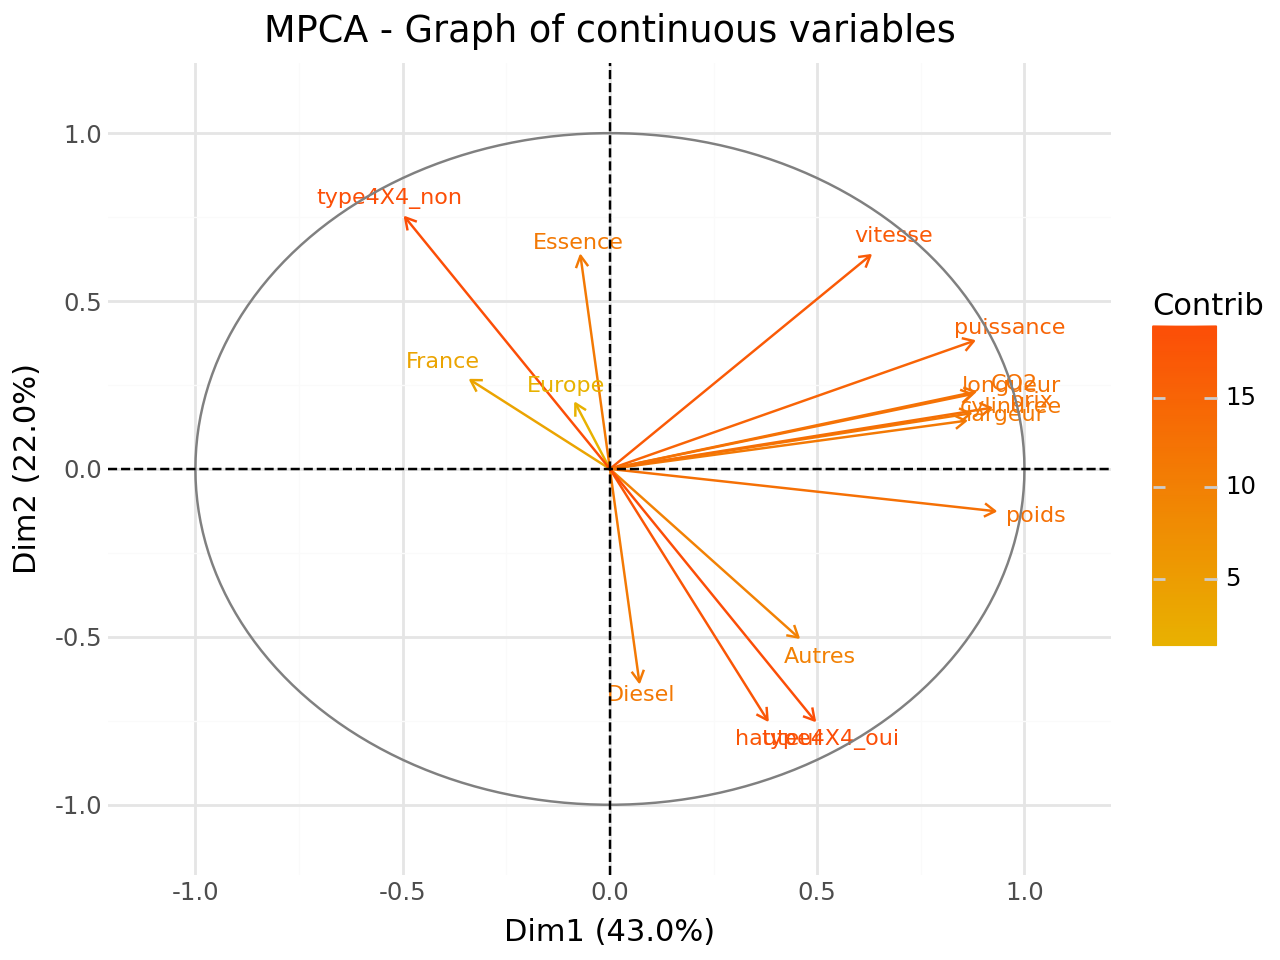

None


In [29]:
# graph of variables - color by contrib
p = fviz_mix(
    obj=clf,
    choice="quanti_var",
    col_var = "contrib",
    repel=True,
    quanti_sup=False
)
print(p.show())

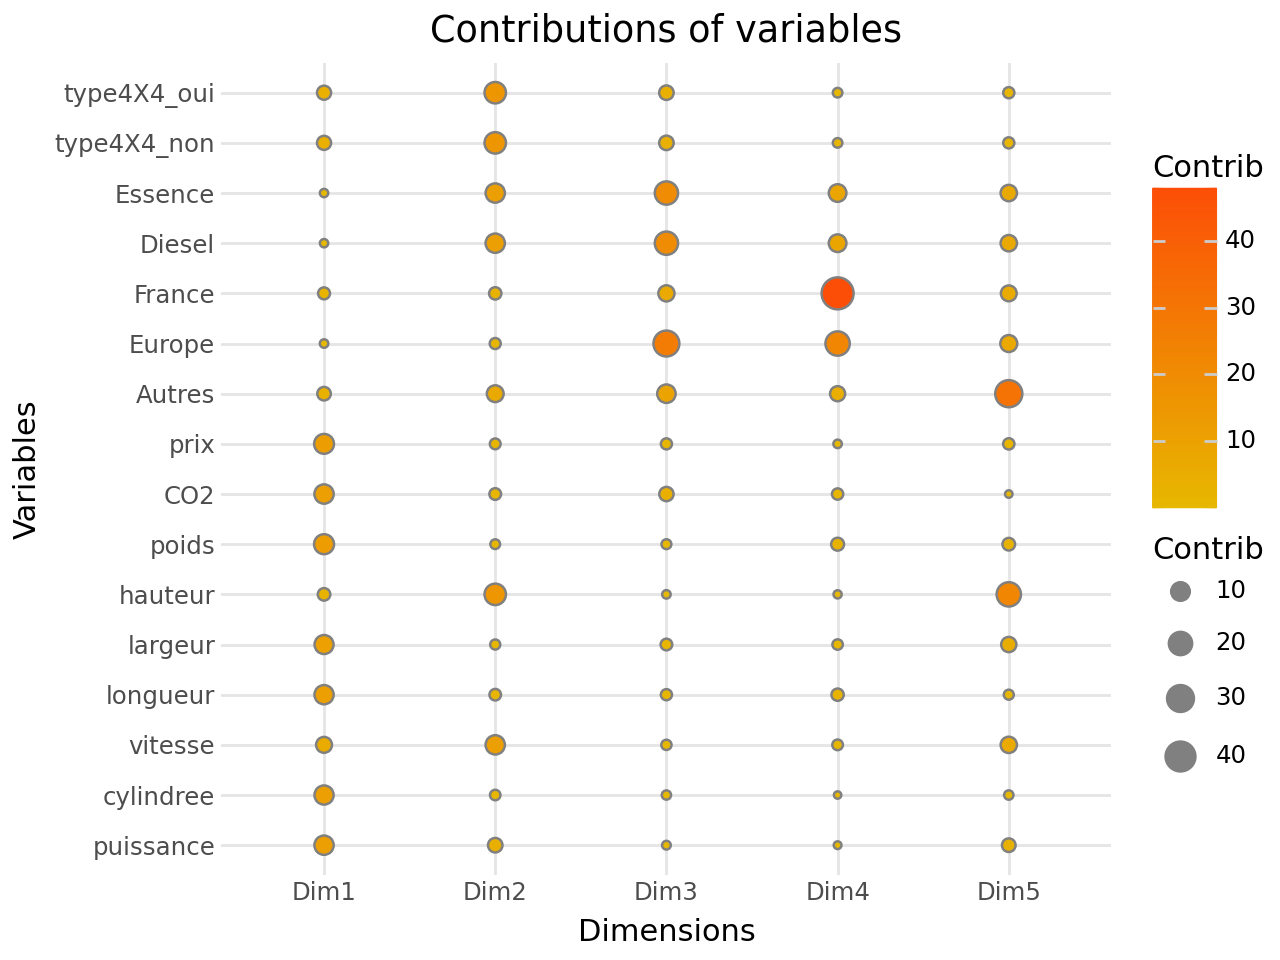

None


In [30]:
# graph of contributions for variables
p = fviz_corrplot(
    X=quanti_var.contrib,
    legend_title="Contrib",
    title="Contributions of variables"
)
print(p.show())

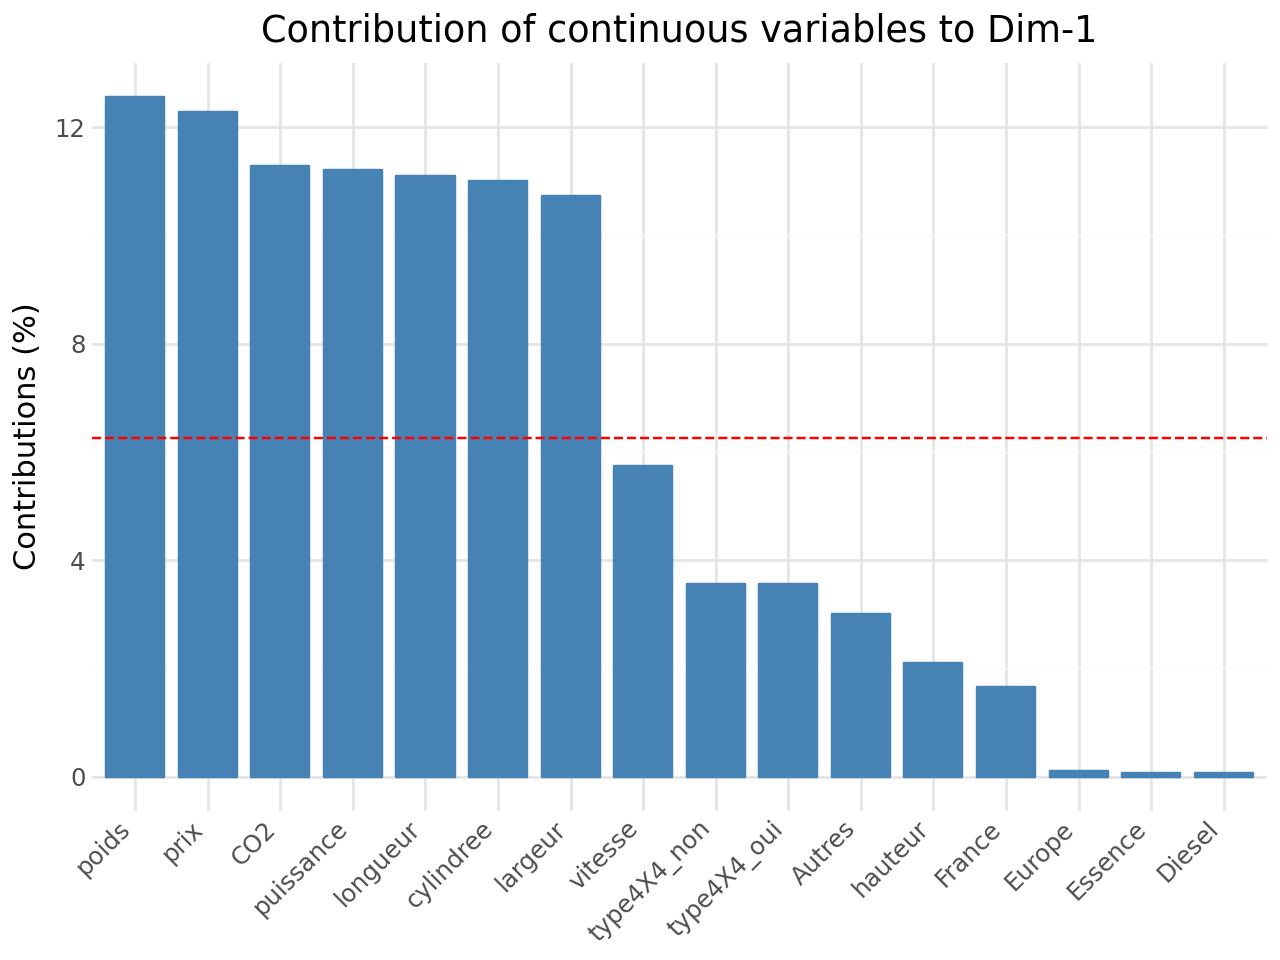

None


In [31]:
# contributions of variables to axis 1
p = fviz_contrib(
    obj=clf,
    choice="quanti_var"
)
print(p.show())

### Quantitative variables cos2

In [32]:
# quantitative variables cos2
quanti_var.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
puissance,0.770699,0.145265,0.003129,0.000163,0.022251
cylindree,0.756558,0.027363,0.006064,0.000002,0.002316
vitesse,0.394777,0.404630,0.013989,0.011165,0.045671
longueur,0.762048,0.049620,0.023881,0.025473,0.003972
largeur,0.737083,0.020578,0.031133,0.009773,0.035375
hauteur,0.144481,0.559593,0.002169,0.000708,0.164151
poids,0.863506,0.015824,0.010620,0.032507,0.015756
CO2,0.775629,0.052698,0.081514,0.016046,0.000009
prix,0.844268,0.033062,0.023172,0.001304,0.008855
Autres,0.206806,0.251902,0.208472,0.062627,0.222973


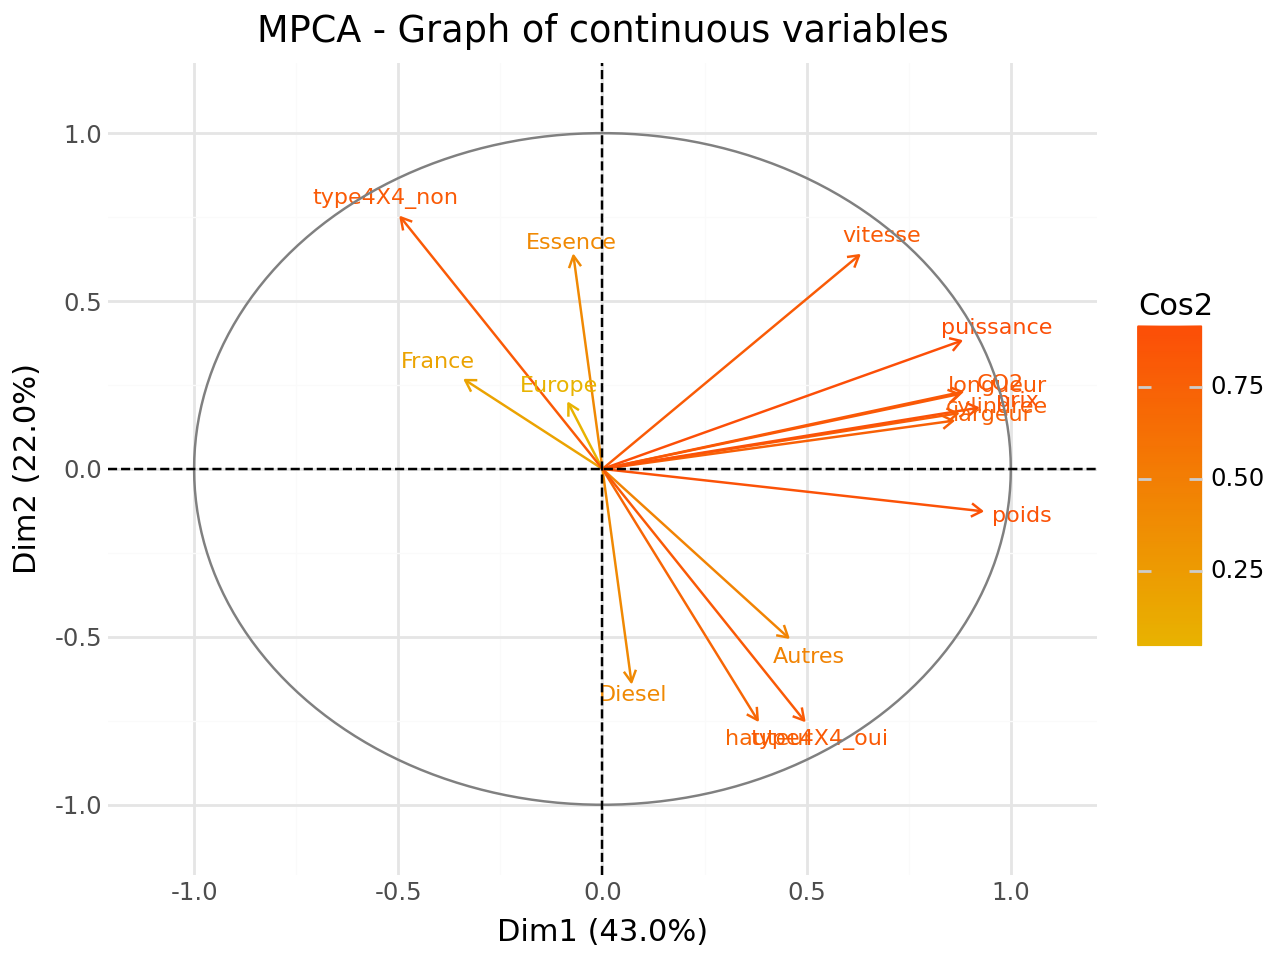

None


In [33]:
# graph of variables - color by cosinus
p = fviz_mix(
    obj=clf,
    choice="quanti_var",
    col_var = "cos2",
    repel=True,
    quanti_sup=False
)
print(p.show())

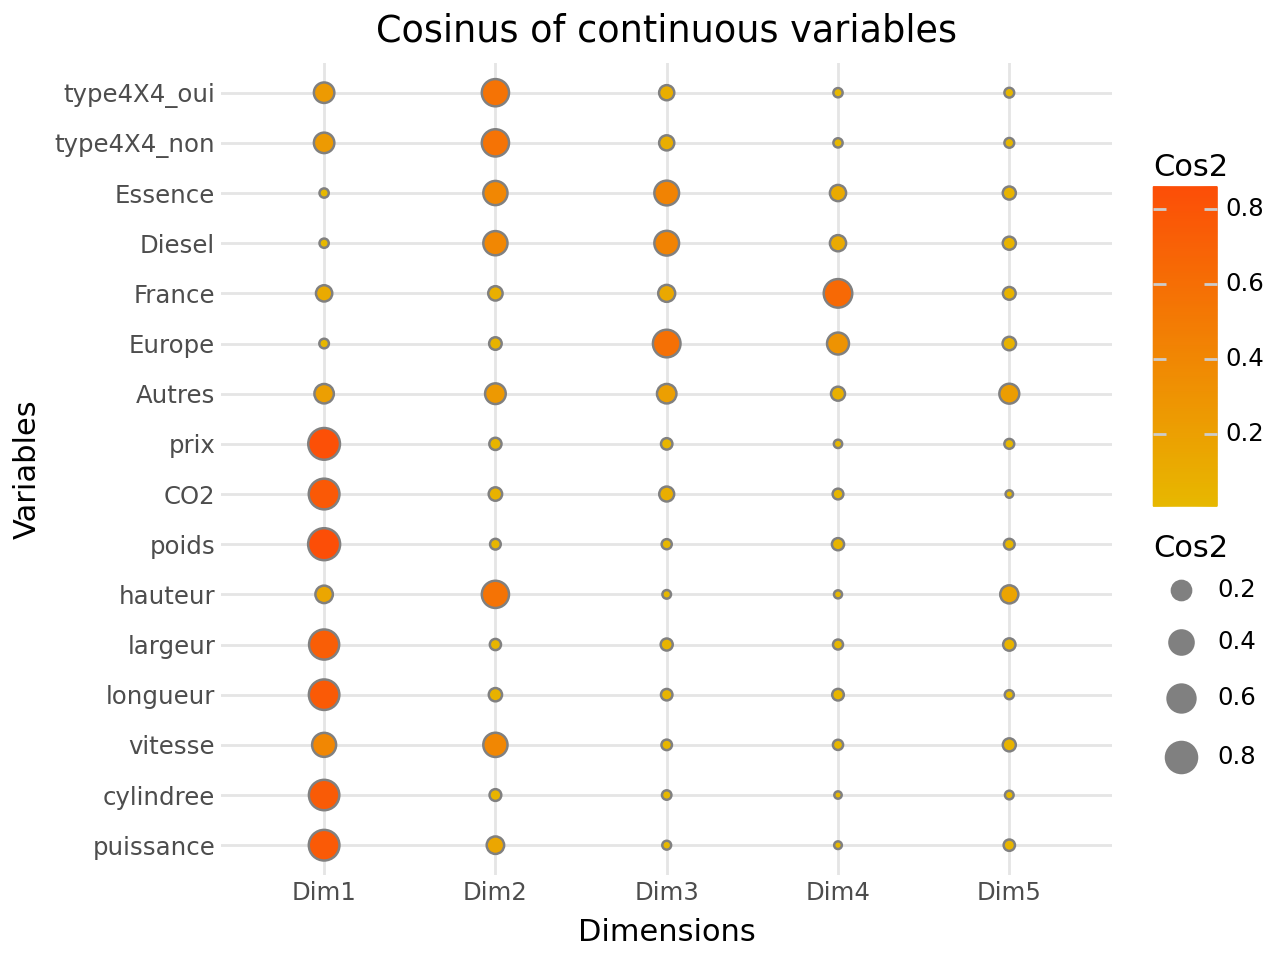

None


In [34]:
# graph of cosinus for variables
p = fviz_corrplot(
    X=quanti_var.cos2,
    legend_title="Cos2",
    title="Cosinus of continuous variables"
)
print(p.show())

### Quantitative variables additionals informations

In [35]:
# quantitative variables additionals informations
quanti_var.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
puissance,1.0,1.0,1.0,6.25
cylindree,1.0,1.0,1.0,6.25
vitesse,1.0,1.0,1.0,6.25
longueur,1.0,1.0,1.0,6.25
largeur,1.0,1.0,1.0,6.25
hauteur,1.0,1.0,1.0,6.25
poids,1.0,1.0,1.0,6.25
CO2,1.0,1.0,1.0,6.25
prix,1.0,1.0,1.0,6.25
Autres,1.0,1.0,1.0,6.25


## Levels informations

In [36]:
# levels informations
levels = clf.levels_
levels._fields

('coord', 'contrib', 'vtest')

### Levels coordinates

In [37]:
# levels coordinates
levels.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
Autres,1.995114,-1.592888,-1.119690,-0.483435,-0.672227
Europe,-0.270347,0.458579,1.384990,-0.786220,0.241497
France,-1.222764,0.696168,-0.736765,1.279050,0.238447
Diesel,0.206833,-1.338512,1.066875,0.427592,-0.203550
Essence,-0.167436,1.083557,-0.863660,-0.346146,0.164778
type4X4_non,-0.504169,0.553032,0.167163,0.031942,-0.029989
type4X4_oui,3.327513,-3.650014,-1.103275,-0.210817,0.197926


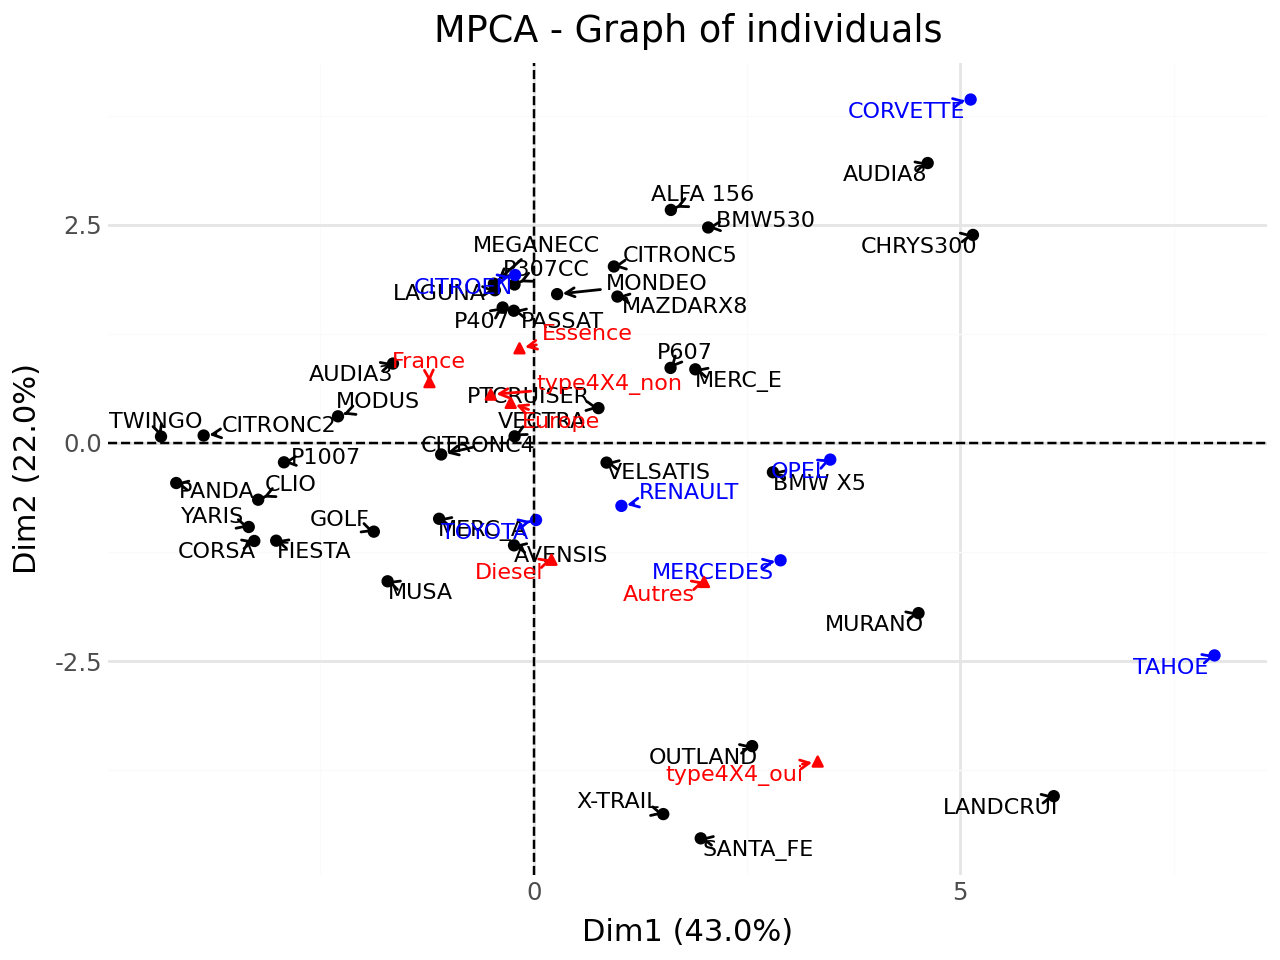

None


In [38]:
# graph of individuals with variable categories
from scientisttools import add_scatter
p = fviz_mix(
    obj=clf,
    choice="ind",
    repel=True
)
# add variable categories
p = add_scatter(
    p = p,
    data = levels.coord,
    color = "red",
    repel = True
)
print(p.show())

### Levels vtest

In [39]:
# levels vtest
levels.vtest

,Dim1,Dim2,Dim3,Dim4,Dim5
Autres,2.766193,-3.052930,-2.777311,-1.522239,-2.872280
Europe,-0.506520,1.187701,4.642310,-3.345415,1.394387
France,-2.045683,1.610002,-2.205143,4.859743,1.229373
Diesel,0.431745,-3.862315,3.984135,2.027071,-1.309410
Essence,-0.431745,3.862315,-3.984135,-2.027071,1.309410
type4X4_non,-3.004980,4.556519,1.782452,0.432373,-0.550833
type4X4_oui,3.004980,-4.556519,-1.782452,-0.432373,0.550833


### Levels contributions

In [40]:
# levels contributions
levels.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
Autres,3.008495,7.002475,9.706384,4.699058,30.805649
Europe,0.100874,1.059819,27.119188,22.695769,7.260118
France,1.645360,1.947471,6.119020,47.892940,5.643446
Diesel,0.073289,11.207616,19.974529,8.332646,6.402177
Essence,0.073289,11.207616,19.974529,8.332646,6.402177
type4X4_non,3.550320,15.598554,3.998010,0.379108,1.132965
type4X4_oui,3.550320,15.598554,3.998010,0.379108,1.132965


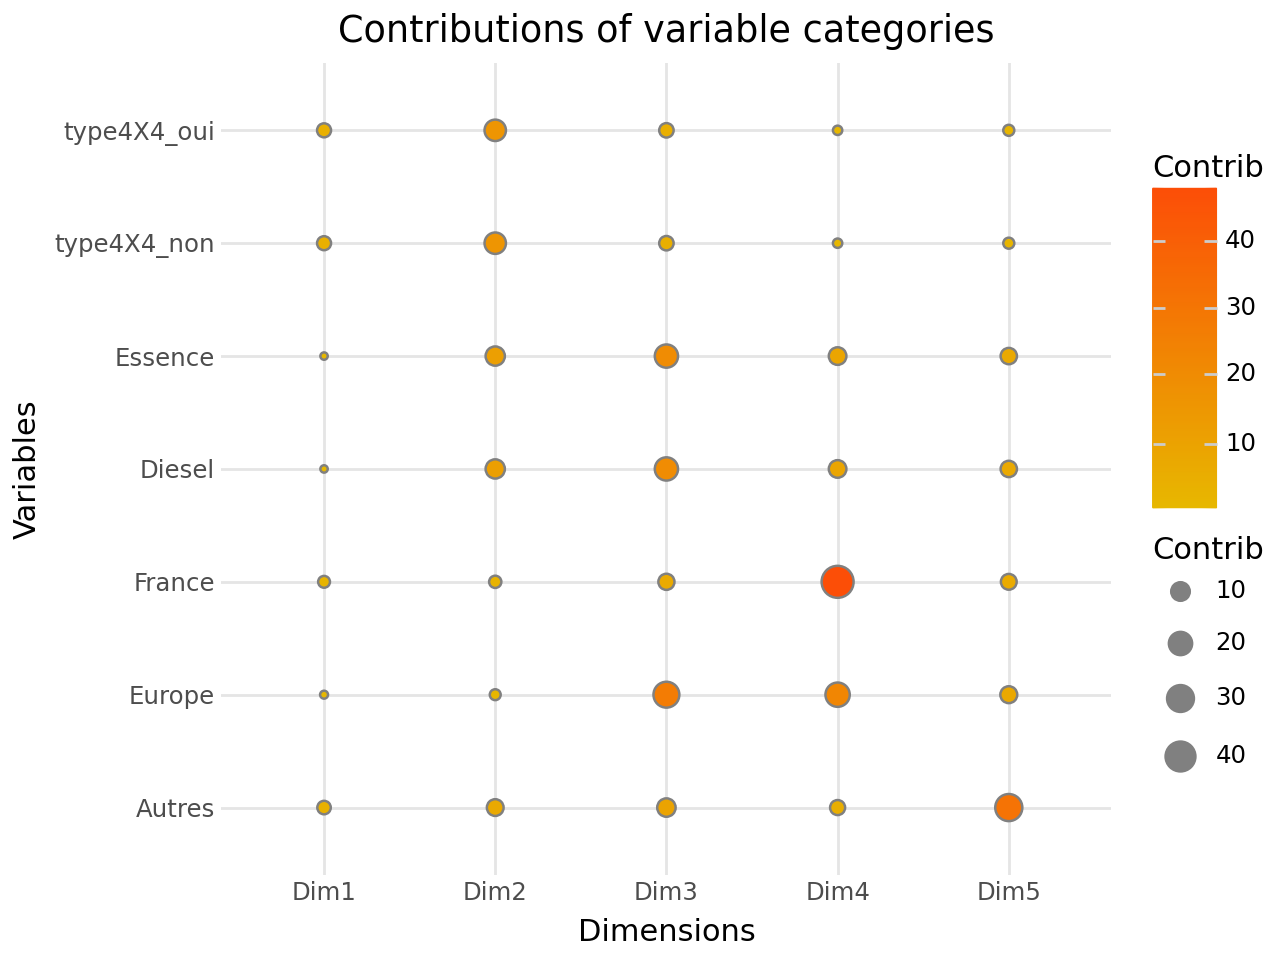

None


In [41]:
# graph of contributions for variable categories
p = fviz_corrplot(
    X=levels.contrib,
    legend_title="Contrib",
    title="Contributions of variable categories"
)
print(p.show())

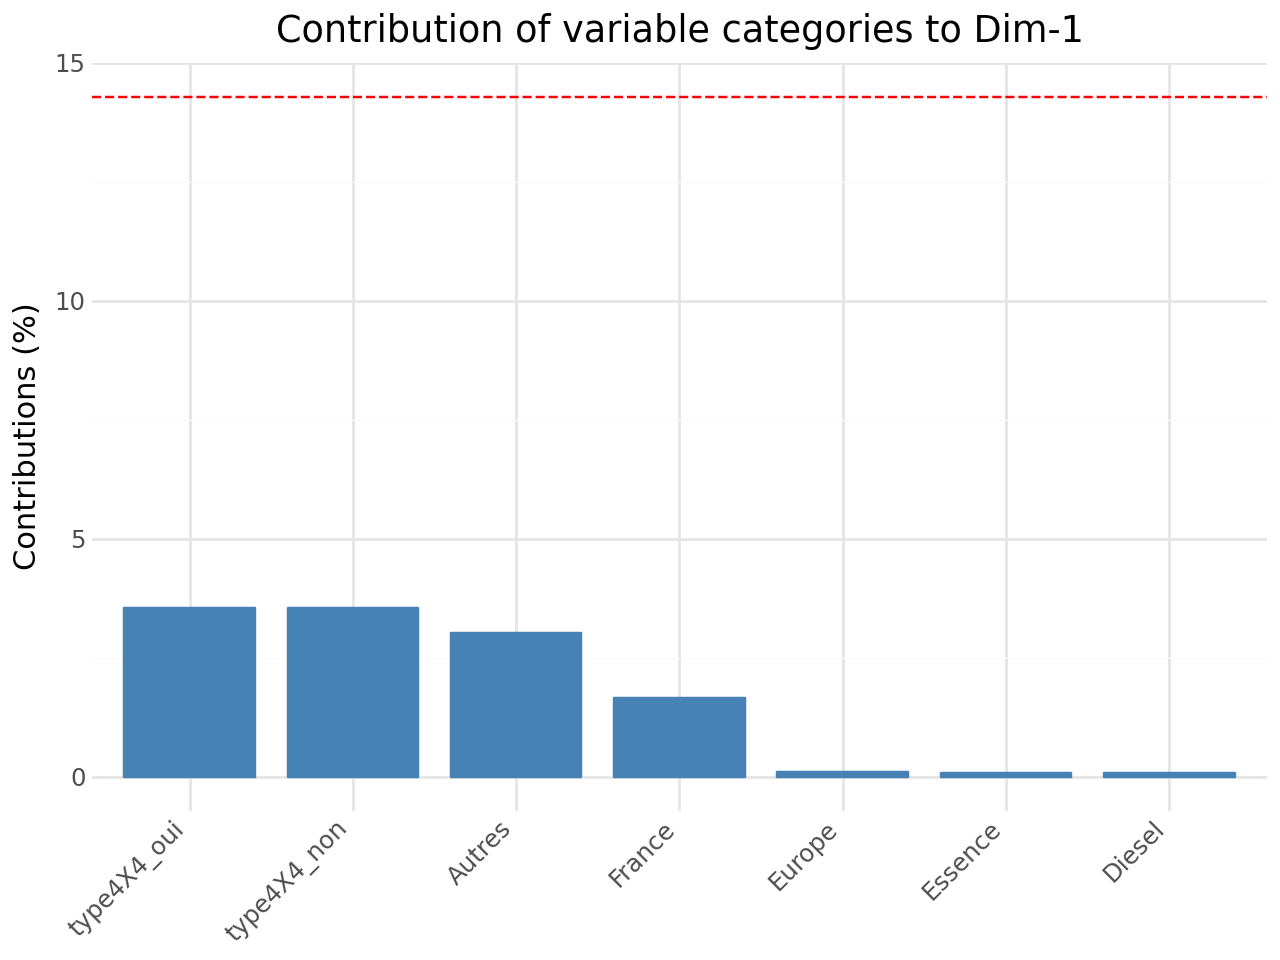

None


In [42]:
# contributions of levels to axis 1
p = fviz_contrib(
    obj=clf,
    choice="levels"
)
print(p.show())

## Variables informations

In [43]:
# variables informations
var = get_mix(clf,"var")
var._fields

('coord', 'contrib')

### Variables coordinates

In [44]:
# variables coordinates
var.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
puissance,0.770699,0.145265,0.003129,0.000163,0.022251
cylindree,0.756558,0.027363,0.006064,0.000002,0.002316
vitesse,0.394777,0.404630,0.013989,0.011165,0.045671
longueur,0.762048,0.049620,0.023881,0.025473,0.003972
largeur,0.737083,0.020578,0.031133,0.009773,0.035375
hauteur,0.144481,0.559593,0.002169,0.000708,0.164151
poids,0.863506,0.015824,0.010620,0.032507,0.015756
CO2,0.775629,0.052698,0.081514,0.016046,0.000009
prix,0.844268,0.033062,0.023172,0.001304,0.008855
origine,0.230990,0.254778,0.592615,0.649161,0.222975


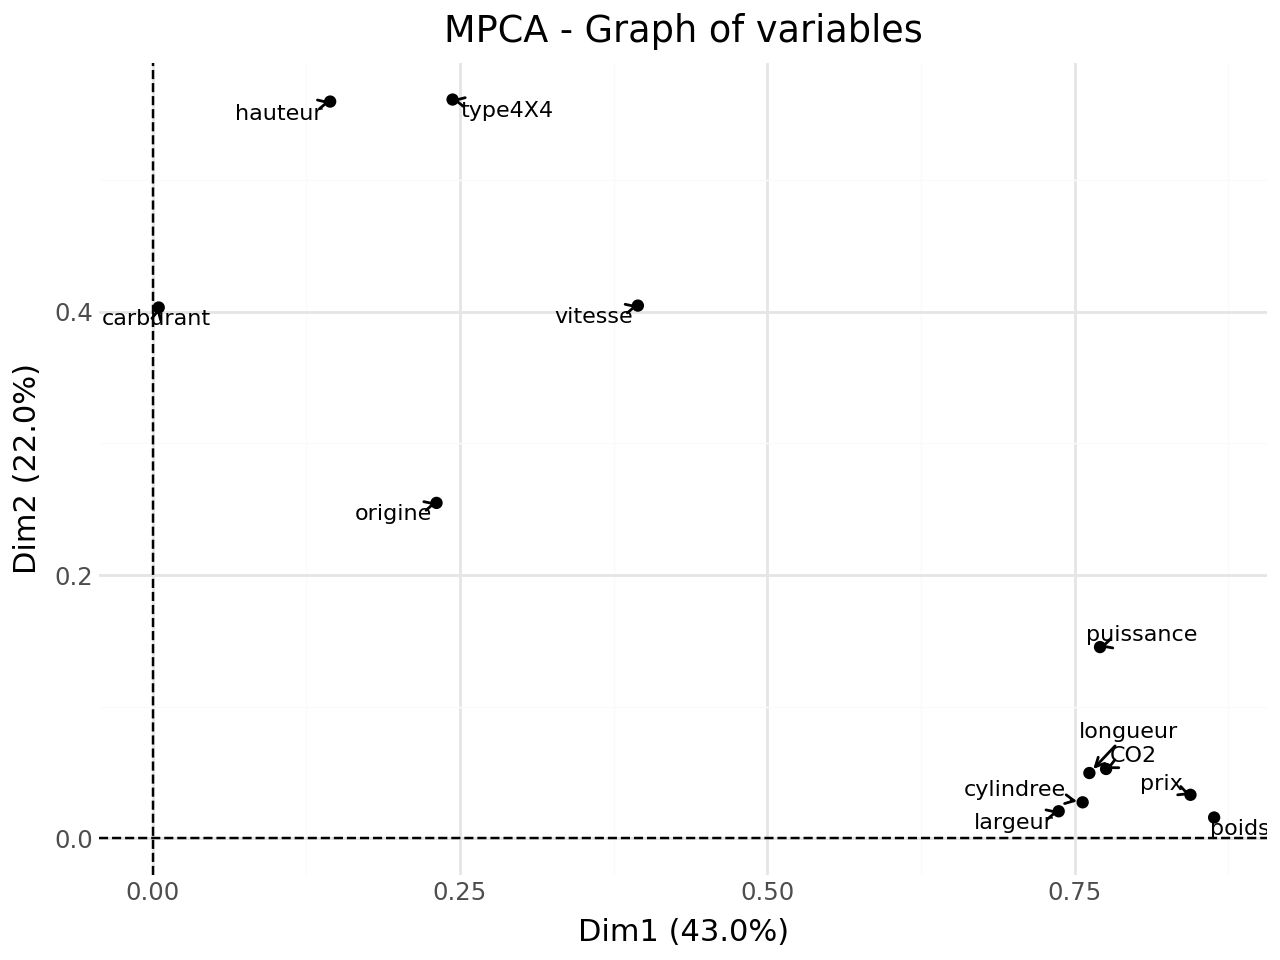

None


In [45]:
# graph of variables
p = fviz_mix(
    obj=clf,
    choice="var",
    repel=True,
    quali_sup = False,
    quanti_sup = False
)
print(p.show())

### Variables contributions

In [46]:
# variables contributions
var.contrib

,Dim1,Dim2,Dim3,Dim4,Dim5
puissance,11.211682,4.038134,0.145663,0.012203,3.074207
cylindree,11.005964,0.760654,0.282351,0.000136,0.319942
vitesse,5.742991,11.248054,0.651310,0.837760,6.309875
longueur,11.085834,1.379360,1.111889,1.911272,0.548755
largeur,10.722658,0.572035,1.449533,0.733311,4.887342
hauteur,2.101823,15.555791,0.100970,0.053140,22.678868
poids,12.561790,0.439874,0.494459,2.439086,2.176885
CO2,11.283397,1.464925,3.795263,1.203941,0.001288
prix,12.281915,0.919069,1.078893,0.097877,1.223341
origine,4.754728,10.009765,42.944592,75.287767,43.709212


## Supplementary individuals informations

In [47]:
# supplementary individuals informations
ind_sup = clf.ind_sup_
ind_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary individuals coordinates

In [48]:
# supplementary individuals coordinates
ind_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
CORVETTE,5.120157,3.933229,-1.066405,-0.670136,-2.854118
TAHOE,7.978873,-2.434044,-2.137578,-0.672008,3.196996
OPEL,3.474969,-0.191124,1.141819,2.545786,1.625304
RENAULT,1.027079,-0.721394,-2.535341,0.287673,1.416015
CITROEN,-0.218810,1.923365,0.595770,-1.631989,0.535246
TOYOTA,0.026317,-0.882890,0.952810,0.395842,-1.591703
MERCEDES,2.892568,-1.344793,0.313549,-1.503654,-0.171219


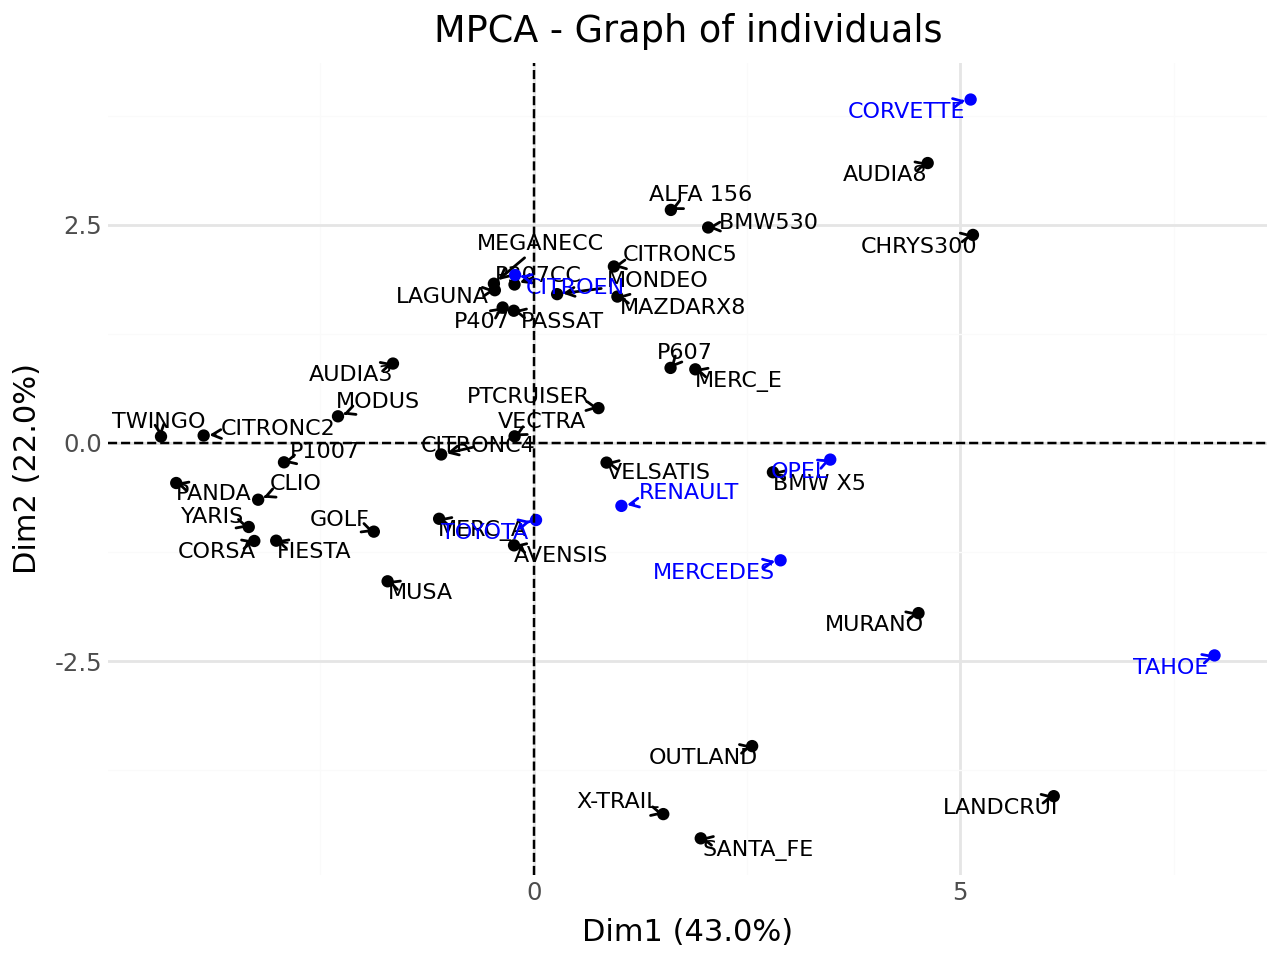

None


In [49]:
# graph of individuals
from scientisttools import fviz_mix
p = fviz_mix(
    obj=clf,
    choice="ind",
    col_ind = "black",
    repel = True,
    ind_sup = True
)
print(p.show())

### Supplementary individuals cos2

In [50]:
# individuals cos2
ind_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
CORVETTE,0.422839,0.249521,0.018342,0.007243,0.131387
TAHOE,0.672972,0.062628,0.048301,0.004774,0.108043
OPEL,0.260581,0.000788,0.028134,0.139857,0.057005
RENAULT,0.034930,0.017232,0.212843,0.002740,0.066393
CITROEN,0.002590,0.200151,0.019204,0.144102,0.015500
TOYOTA,0.000037,0.041450,0.048275,0.008332,0.134721
MERCEDES,0.141979,0.030688,0.001668,0.038366,0.000497


### Supplementary individuals dist2

In [51]:
# supplementary individuals dist2
ind_sup.dist2.to_frame()

,Sq. Dist.
CORVETTE,61.999995
TAHOE,94.598855
OPEL,46.340311
RENAULT,30.200473
CITROEN,18.482707
TOYOTA,18.805720
MERCEDES,58.931006


## Supplementary quantitative variables informations

In [52]:
# supplementary quantitative variables
quanti_var_sup = clf.quanti_var_sup_
quanti_var_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary quantitative variables coordinates

In [53]:
# supplementary quantitative variables coordinates
quanti_var_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
coffre,0.606857,-0.094977,0.338508,0.025336,-0.002622
reservoir,0.877189,0.069962,0.178553,0.225042,0.152126
consommation,0.820596,0.303339,-0.373624,-0.171807,0.022697


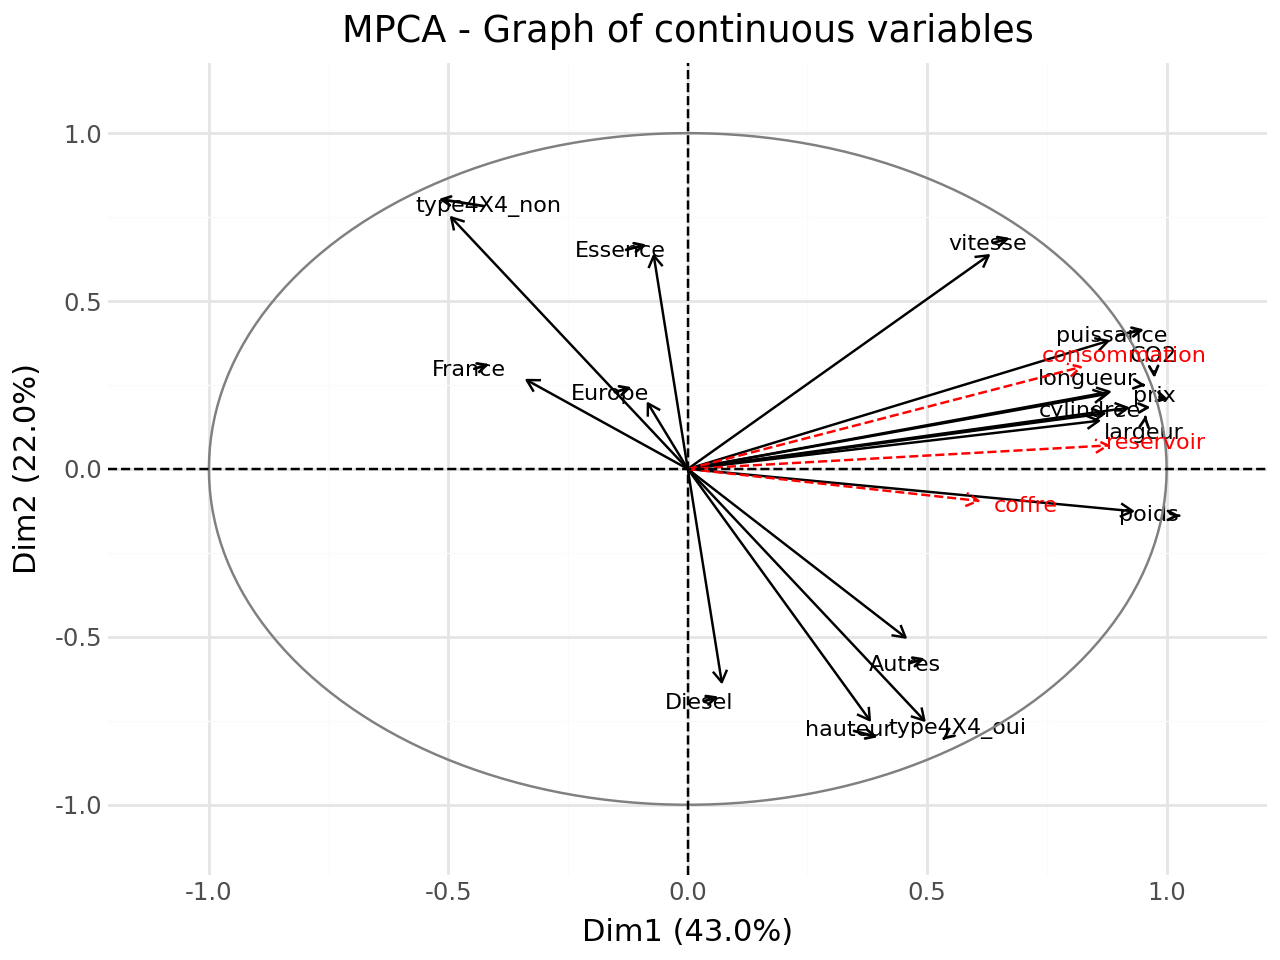

None


In [54]:
# graph of variables - correlation circle
p = fviz_mix(
    obj=clf,
    choice="quanti_var",
    repel=True,
    quanti_sup=True
)
print(p.show())

### Supplementary quantitative variables cos2

In [55]:
# supplementary quantitative variables cos2
quanti_var_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
coffre,0.368276,0.009021,0.114588,0.000642,0.000007
reservoir,0.769460,0.004895,0.031881,0.050644,0.023142
consommation,0.673377,0.092014,0.139595,0.029517,0.000515


## Supplementary levels informations

In [56]:
# supplementary levels informations
levels_sup = clf.levels_sup_
levels_sup._fields

('coord', 'cos2', 'dist2', 'coord_n', 'vtest')

### Supplementary levels coordinates

In [57]:
# supplementary levels coordinates
levels_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
surtaxe_non,-0.151007,0.398768,-0.150363,-0.03313,0.101677
surtaxe_oui,0.151007,-0.398768,0.150363,0.03313,-0.101677


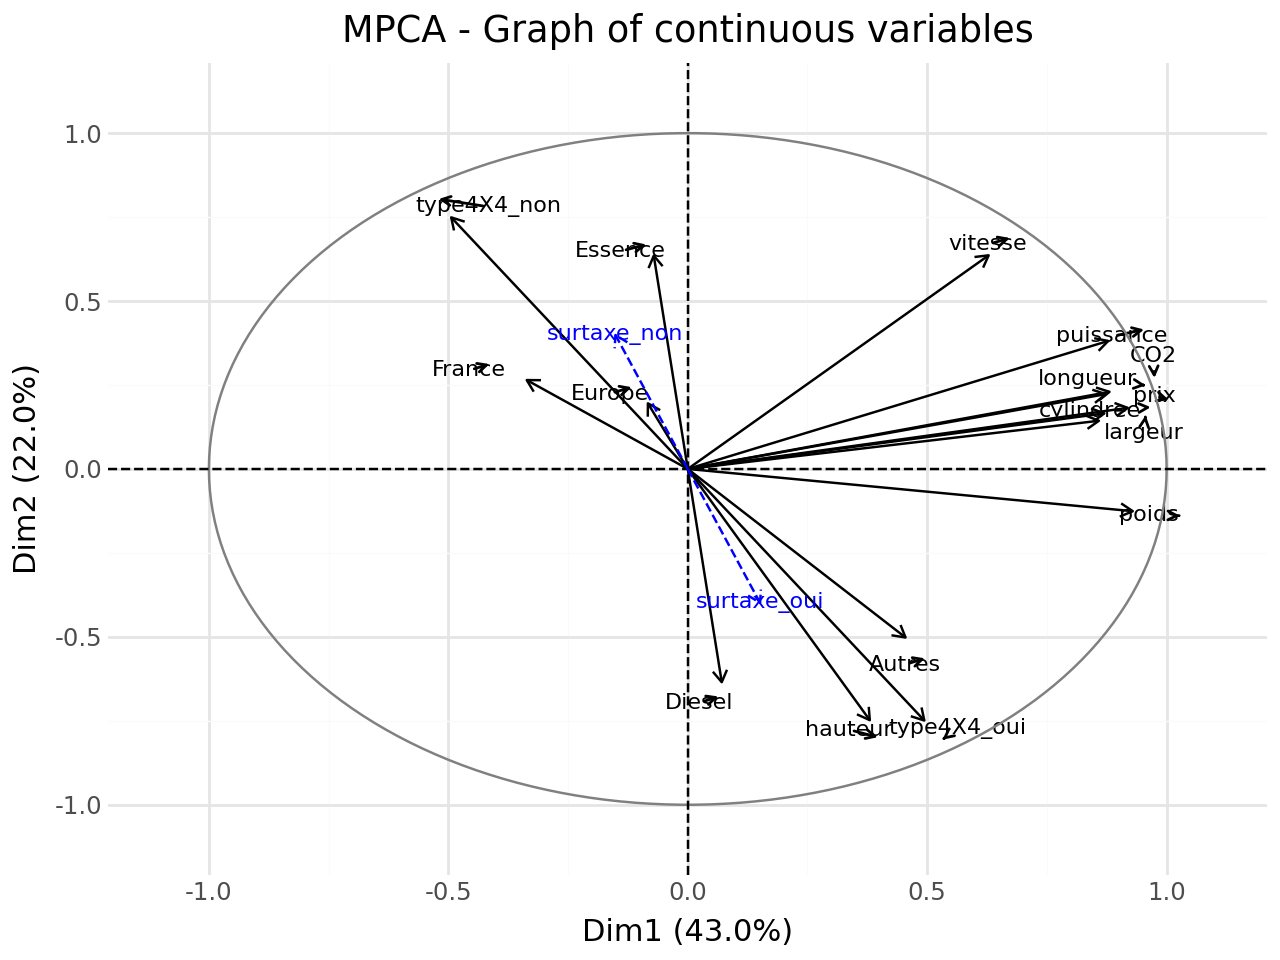

None


In [58]:
# graph of variables - correlation circle
from scientisttools import add_arrow
p = fviz_mix(
    obj=clf,
    choice="quanti_var",
    repel=True,
    quanti_sup=False
)
# add levels coordinates
p = add_arrow(
    p = p, 
    data= levels_sup.coord
)
print(p.show())

### Supplementary levels coordinates - barycenters

In [59]:
# supplementary levels coordinates barycenters
levels_sup.coord_n

,Dim1,Dim2,Dim3,Dim4,Dim5
surtaxe_non,-0.490255,0.936546,-0.272869,-0.047361,0.107116
surtaxe_oui,0.319731,-0.610791,0.177958,0.030887,-0.069858


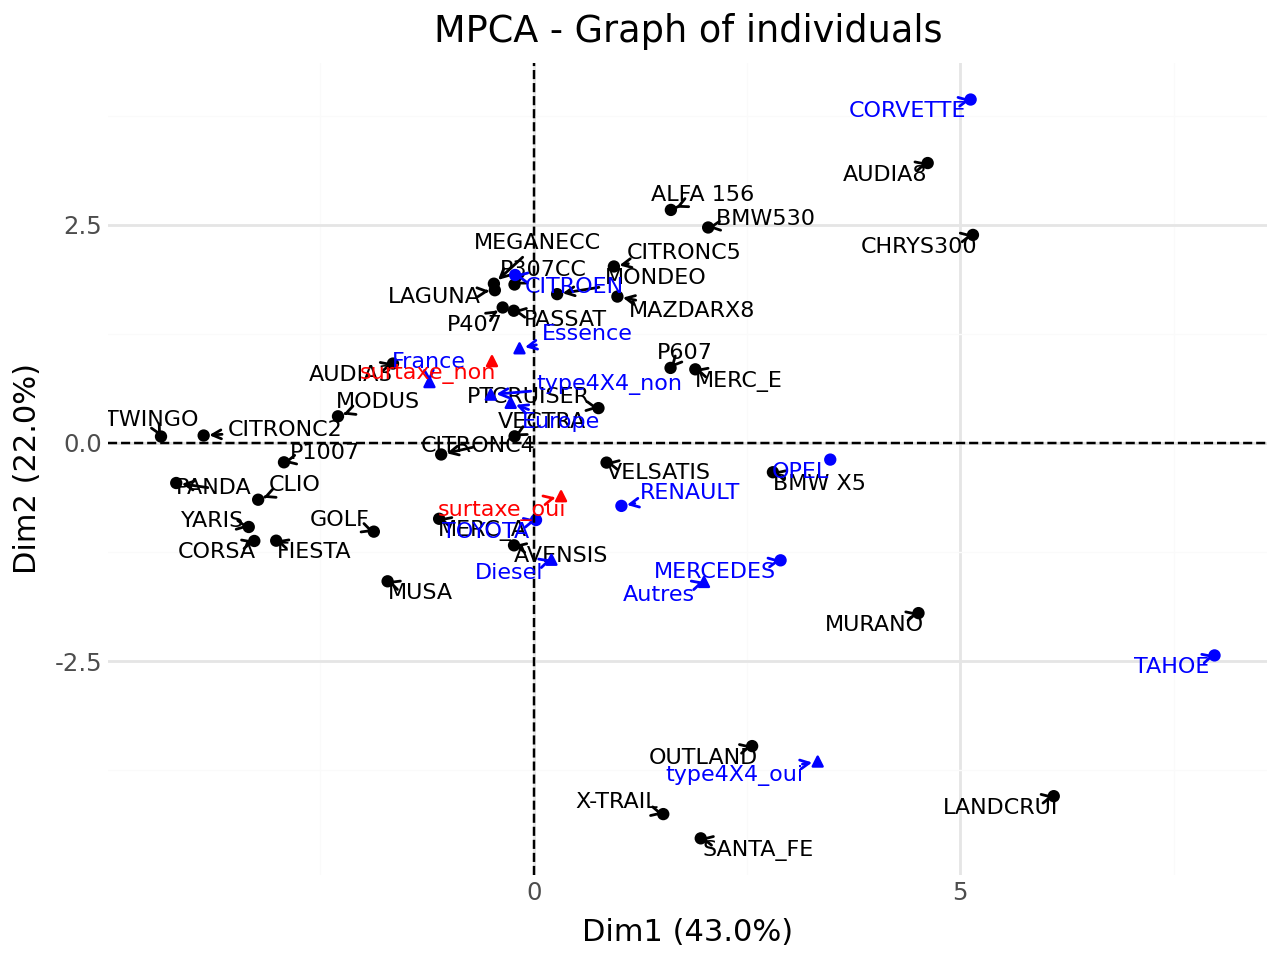

None


In [60]:
# graph of individuals with variable categories
from scientisttools import add_scatter
p = fviz_mix(
    obj=clf,
    choice="ind",
    repel=True
)
# add variable categories
p = add_scatter(
    p = p,
    data = levels.coord,
    color = "blue",
    repel = True
)
# add supplementary variable categories
p = add_scatter(
    p = p,
    data = levels_sup.coord_n,
    color = "red",
    repel = True
)
print(p.show())

### Supplementary levels vtest

In [61]:
# supplementary levels vtest
levels_sup.vtest

,Dim1,Dim2,Dim3,Dim4,Dim5
surtaxe_non,-0.918538,2.425612,-0.914623,-0.201522,0.618478
surtaxe_oui,0.918538,-2.425612,0.914623,0.201522,-0.618478


### Supplementary levels cos2

In [62]:
# supplementary levels cos2
levels_sup.cos2

,Dim1,Dim2,Dim3,Dim4,Dim5
surtaxe_non,0.022803,0.159016,0.022609,0.001098,0.010338
surtaxe_oui,0.022803,0.159016,0.022609,0.001098,0.010338


### Supplementary levels dist2

In [63]:
# supplementary levels dist2
levels_sup.dist2.to_frame()

,Sq. Dist.
surtaxe_non,1.0
surtaxe_oui,1.0


## Supplementary qualitative variables informations

In [64]:
# supplementary qualitative variables informations
quali_var_sup = clf.quali_var_sup_
quali_var_sup._fields

('coord',)

### Supplementary qualitative variables coordinates

In [65]:
# supplementary qualitative variables coordinates
quali_var_sup.coord

,Dim1,Dim2,Dim3,Dim4,Dim5
surtaxe,0.022803,0.159016,0.022609,0.001098,0.010338


## Others functions

### Ellipses - `fviz_ellipses`

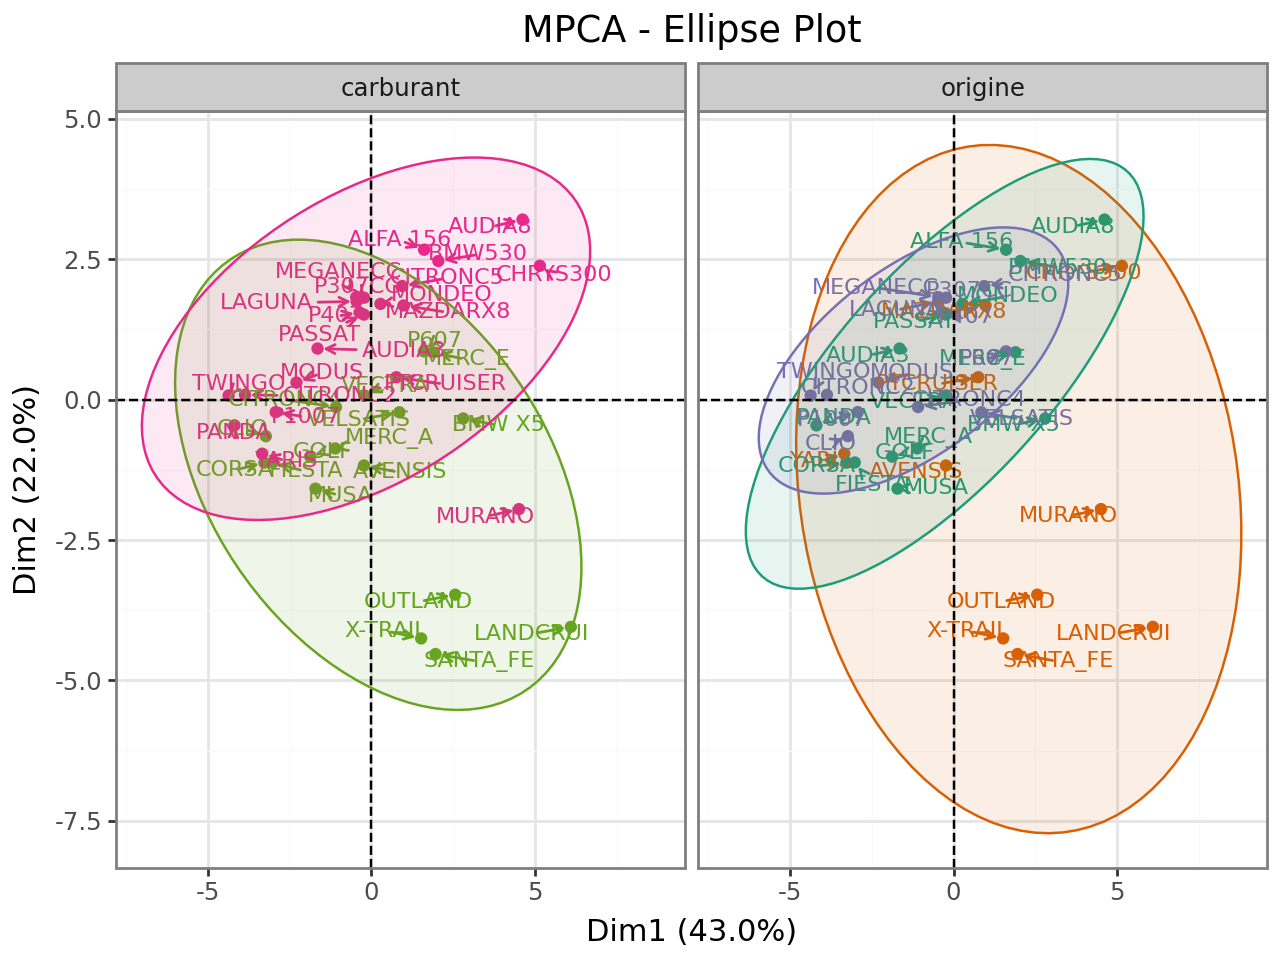

None


In [66]:
# ellipses
from scientisttools import fviz_ellipses
p = fviz_ellipses(
    obj=clf,
    habillage=["origine","carburant"],
    repel=True,
    add_ellipses=True
)
print(p.show())

### Summaries - `summary`

In [67]:
# summary
from scientisttools import summary
summary(clf)

                     Mixed Principal Component Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      6.8741      3.2767         42.9629         42.9629
Dim2      3.5973      1.4495         22.4833         65.4463
Dim3      2.1478      0.8150         13.4236         78.8699

Individuals (the 10 first):
            Dim1    cos2      ctr    Dim2    cos2     ctr    Dim3    cos2  \
ALFA 156  1.6067  0.1764   0.9883  2.6688  0.4867  5.2103  0.2367  0.0038   
AUDIA3   -1.6504  0.3771   1.0428  0.9090  0.1144  0.6045  0.2889  0.0116   
AUDIA8    4.6169  0.5817   8.1602  3.2058  0.2804  7.5179  1.0933  0.0326   
AVENSIS  -0.2315  0.0065   0.0205 -1.1732  0.1677  1.0069  0.5463  0.0364   
BMW X5    2.8029  0.4346   3.0076 -0.3359  0.0062  0.0825  2.4989  0.3454   
BMW530    2.0438  0.3310   1.5992  2.4677  0.4826  4.4548  0.7054  0.0394   
CHRYS300  5.1474  0.6548  10.1432  2.3824  0.1403  4.1521 -0.9931  0.0244 

In [68]:
# formatting text to markdown
summary(clf,to_markdown=True)

                     Mixed Principal Component Analysis - Results                     

Importance of components:
        Eigenvalue    Difference    Proportion (%)    Cumulative (%)
----  ------------  ------------  ----------------  ----------------
Dim1        6.8741        3.2767           42.9629           42.9629
Dim2        3.5973        1.4495           22.4833           65.4463
Dim3        2.1478        0.815            13.4236           78.8699

Individuals (the 10 first):
             Dim1    cos2      ctr     Dim2    cos2     ctr     Dim3    cos2     ctr
--------  -------  ------  -------  -------  ------  ------  -------  ------  ------
ALFA 156   1.6067  0.1764   0.9883   2.6688  0.4867  5.2103   0.2367  0.0038  0.0686
AUDIA3    -1.6504  0.3771   1.0428   0.909   0.1144  0.6045   0.2889  0.0116  0.1023
AUDIA8     4.6169  0.5817   8.1602   3.2058  0.2804  7.5179   1.0933  0.0326  1.4644
AVENSIS   -0.2315  0.0065   0.0205  -1.1732  0.1677  1.0069   0.5463  0.0364  0.3657
BM

### Dimension description - `dimdesc`

In [69]:
# dimension description
from scientisttools import dimdesc
dim_desc = dimdesc(clf,axis=[0,1])
dim_desc.keys()

dict_keys(['Dim1', 'Dim2'])

### `Dim1` dimension

In [70]:
# Dim1 dimension
dim_desc["Dim1"]._fields

('call', 'quanti', 'quali', 'category')

#### Description of Dim1 by quantitative variables

In [71]:
# description of Dim1 by quantitative variables
dim_desc["Dim1"].quanti

,correlation,pvalue
poids,0.929250,3.827130e-17
prix,0.918840,4.152141e-16
CO2,0.880698,3.091058e-13
puissance,0.877895,4.584564e-13
reservoir,0.877189,5.055442e-13
longueur,0.872954,8.976037e-13
cylindree,0.869803,1.357909e-12
largeur,0.858535,5.492332e-12
consommation,0.820596,2.845046e-10
vitesse,0.628313,2.404204e-05


#### Description of Dim1 by levels

In [72]:
# description of Dim1 by levels
dim_desc["Dim1"].category

,Estimate,pvalue
origine=Autres,2.707655,0.004125
origine=France,-1.858602,0.038975
type4X4=type4X4_non,-3.831681,0.001620
type4X4=type4X4_oui,3.831681,0.001620


#### Description of Dim1 by qualitative variables

In [73]:
# description of Dim1 by qualitative variables
dim_desc["Dim1"].quali

,R2,pvalue
type4X4,0.244052,0.001620
origine,0.230990,0.010088
